# D_S3 — 27 Representative Scatterplots Tree Check

This notebook keeps only one representative scatterplot per relationship family: F01-F26 plus Null.

Flow:
1. Select 27 representative cases.
2. Visualize the 27 raw scatterplots.
3. Classify whether each has a global relationship using the same `D_S2.0` rule.
4. For global-relationship cases only, classify Simple vs Complex using the same `D_S2.0` logic.


In [1]:
# ── Imports and paths ──
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.0)
plt.rcParams['figure.dpi'] = 120

S1_DIR = Path('output/S1')
S2_DIR = Path('output/S2')


In [2]:
# ── Settings: one representative case per family ──
USE_STRONG =  True
USE_STANDARD = False
USE_MILD = False

TARGET_SNR = 20.0
TARGET_REPLICATE = 0

# Same as D_S2.0 Step 1.
MIC_THRESH = 0.8
DCOR_THRESH = 0

# Same as D_S2.0 Simple/Complex step.
R_THRESH = 0.7
MR_THRESH = 1.0
REVERSAL_PROMINENCE = 0.10




In [3]:
# ── Load data ──
cases_full = pd.read_csv(S1_DIR / 'cases.csv', low_memory=False)
metrics = pd.read_parquet(S2_DIR / 'metrics_full.parquet')

meta_cols = [
    'case_id', 'family_id', 'family_name', 'snr', 'spread_pattern',
    'x_distribution', 'category', 'direction', 'linearity',
    'monotonicity', 'special_shape', 'replicate', 'variant_level',
]
meta = cases_full[[c for c in meta_cols if c in cases_full.columns]].copy()

df = metrics.merge(meta, on='case_id', how='left')
df['snr_val'] = df['snr'].apply(lambda x: float('inf') if str(x) == 'inf' else float(x))

allowed_levels = []
if USE_STRONG:
    allowed_levels.append('strong')
if USE_STANDARD:
    allowed_levels.append('standard')
if USE_MILD:
    allowed_levels.append('mild')
allowed_levels.append('none')  # Null

df = df[df['variant_level'].isin(allowed_levels)].copy()

print(f'Variant levels loaded: {allowed_levels}')
print(f'Total loaded cases: {len(df):,}')
print(f'Signal cases: {(df["family_id"] != "Null").sum():,}')
print(f'Null cases: {(df["family_id"] == "Null").sum():,}')


Variant levels loaded: ['strong', 'none']
Total loaded cases: 54,270
Signal cases: 52,260
Null cases: 2,010


In [4]:
# ── Labels and colors ──
FAMILY_PALETTE = {
    'F01': '#4FC3F7',  'F02': '#29B6F6',  'F03': '#81C784',  'F04': '#26C6DA',
    'F05': '#AED581',  'F06': '#43A047',  'F07': '#F48FB1',  'F08': '#CE93D8',
    'F09': '#80DEEA',  'F10': '#80CBC4',  'F11': '#FFE082',  'F12': '#F9A825',
    'F13': '#8D6E63',  'F14': '#A1887F',  'F15': '#78909C',  'F16': '#90A4AE',
    'F17': '#C62828',  'F18': '#AD1457',  'F19': '#6A1B9A',  'F20': '#4527A0',
    'F21': '#1565C0',  'F22': '#00838F',  'F23': '#2E7D32',  'F24': '#FF7043',
    'F25': '#D84315',  'F26': '#4E342E',  'Null': '#BDBDBD',
}

SHORT = {
    'F01': 'Linear(+)',     'F02': 'Linear(-)',     'F03': 'PwrCvx(+)',
    'F04': 'PwrCvx(-)',    'F05': 'PwrCcv(+)',     'F06': 'PwrCcv(-)',
    'F07': 'Sat(+)',        'F08': 'Sat(-)',        'F09': 'Log(+)',
    'F10': 'Log(-)',        'F11': 'Exp(+)',        'F12': 'Exp(-)',
    'F13': 'S-crv(+)',      'F14': 'S-crv(-)',      'F15': 'Thresh(+)',
    'F16': 'Thresh(-)',     'F17': 'Peak',          'F18': 'Valley',
    'F19': 'Spike',         'F20': 'Inv Spike',     'F21': 'Cubic',
    'F22': 'Oscillation',   'F23': 'Two Lines',     'F24': 'L+Parab',
    'F25': 'Multi-reg',     'F26': 'Windowed J',    'Null': 'No relationship',
}

FAMILY_IDS_27 = [f'F{i:02d}' for i in range(1, 27)] + ['Null']


In [5]:
# ── Select 27 representative cases: F01-F26 + Null ──
def _finite_positive_snr(s):
    return np.isfinite(s) & (s > 0)


def pick_representative_case(fid, target_snr=TARGET_SNR, target_replicate=TARGET_REPLICATE):
    sub = df[df['family_id'] == fid].copy()
    sub = sub[_finite_positive_snr(sub['snr_val'])].copy()
    if len(sub) == 0:
        return None

    closest_snr = sub['snr_val'].iloc[(sub['snr_val'] - target_snr).abs().argmin()]
    sub = sub[sub['snr_val'] == closest_snr].copy()

    rep_sub = sub[sub['replicate'] == target_replicate]
    if len(rep_sub) > 0:
        sub = rep_sub

    return sub.sort_values('case_id').iloc[0]


rows = []
for fid in FAMILY_IDS_27:
    row = pick_representative_case(fid)
    if row is not None:
        rows.append(row)

cases_27 = pd.DataFrame(rows).reset_index(drop=True)
cases_27['short'] = cases_27['family_id'].map(SHORT)

print(f'Selected cases: {len(cases_27)} / 27')
print(f'Requested SNR ~= {TARGET_SNR}, replicate = {TARGET_REPLICATE}')
print(f'Actual SNR values selected: {sorted(cases_27["snr_val"].unique())}')

display(cases_27[[
    'family_id', 'short', 'case_id', 'variant_level', 'snr_val', 'replicate',
    'MIC', 'distance_correlation', 'pearson_r', 'spearman_rho', 'MIC_minus_r2', 'MAS',
]].round(3))


Selected cases: 27 / 27
Requested SNR ~= 20.0, replicate = 0
Actual SNR values selected: [19.75631915631101]


,family_id,short,case_id,variant_level,snr_val,replicate,MIC,distance_correlation,pearson_r,spearman_rho,MIC_minus_r2,MAS
0,F01,Linear(+),5521,strong,19.756,0,0.944,0.973,0.977,0.978,-0.010,0.022
1,F02,Linear(-),11551,strong,19.756,0,0.967,0.973,-0.978,-0.978,0.011,0.039
2,F03,PwrCvx(+),17581,strong,19.756,0,0.830,0.864,0.832,0.850,0.139,0.081
3,F04,PwrCvx(-),23611,strong,19.756,0,0.803,0.870,-0.836,-0.848,0.104,0.044
4,F05,PwrCcv(+),29641,strong,19.756,0,0.842,0.926,0.896,0.945,0.040,0.047
5,F06,PwrCcv(-),35671,strong,19.756,0,0.862,0.926,-0.901,-0.955,0.051,0.025
6,F07,Sat(+),41701,strong,19.756,0,0.558,0.642,0.597,0.603,0.201,0.051
7,F08,Sat(-),47731,strong,19.756,0,0.550,0.617,-0.562,-0.531,0.234,0.070
8,F09,Log(+),53761,strong,19.756,0,0.887,0.921,0.889,0.952,0.096,0.021
9,F10,Log(-),59791,strong,19.756,0,0.883,0.926,-0.902,-0.955,0.069,0.024


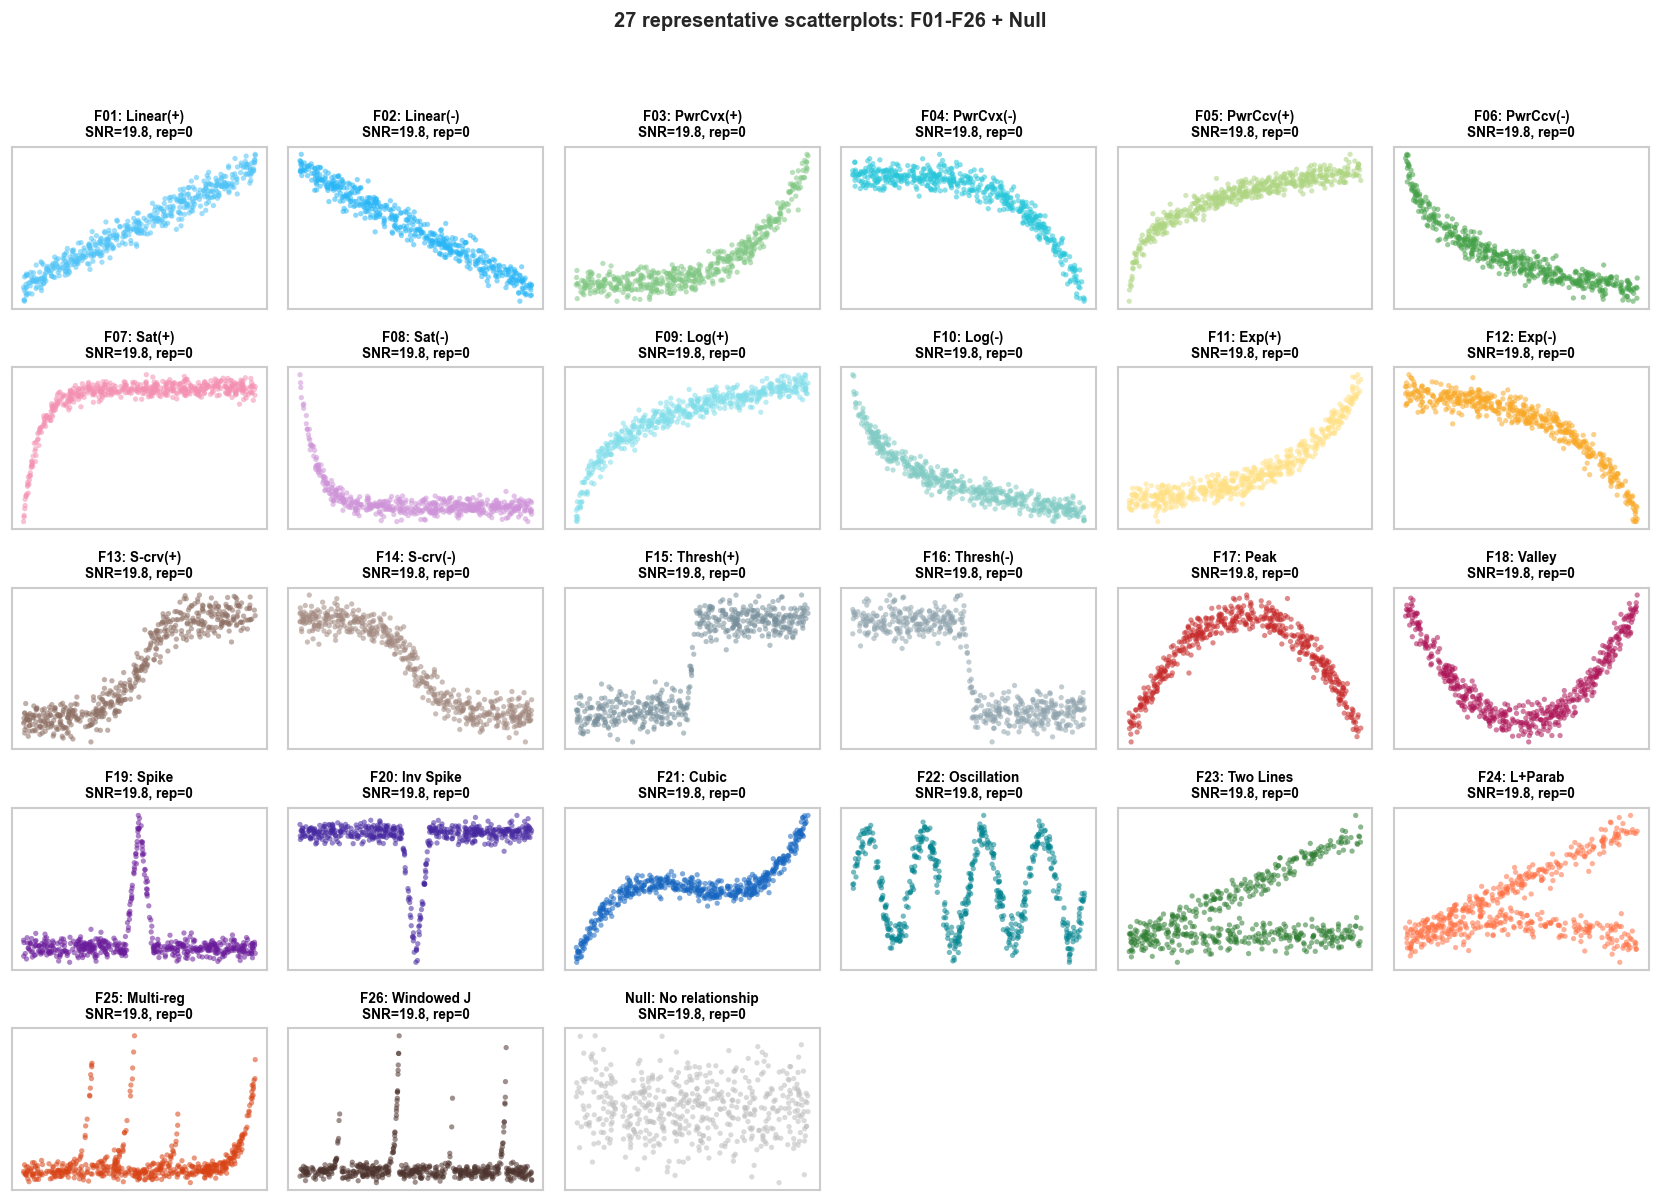

In [6]:
# ── Plot 1: raw 27 representative scatterplots ──
pts = np.load(S1_DIR / 'scatter_points.npz')
x_all, y_all = pts['x'], pts['y']

# scatter_points.npz follows the full cases.csv row order, not the filtered df order.
case_idx_by_id = pd.Series(np.arange(len(cases_full)), index=cases_full['case_id']).to_dict()

fig, axes = plt.subplots(5, 6, figsize=(14, 10))
fig.suptitle('27 representative scatterplots: F01-F26 + Null',
             fontsize=12, fontweight='bold', y=1.0)

for ax, (_, row) in zip(axes.flat, cases_27.iterrows()):
    idx = case_idx_by_id.get(row['case_id'])
    color = FAMILY_PALETTE.get(row['family_id'], '#5b9bd5')
    if idx is not None:
        ax.scatter(x_all[idx], y_all[idx], s=10, alpha=0.55,
                   color=color, edgecolors='none')
    ax.set_title(
        f"{row['family_id']}: {row['short']}\nSNR={row['snr_val']:.3g}, rep={int(row['replicate'])}",
        fontsize=8.2, fontweight='bold', color='black'
    )
    ax.set_xticks([])
    ax.set_yticks([])

for ax in axes.flat[len(cases_27):]:
    ax.set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()




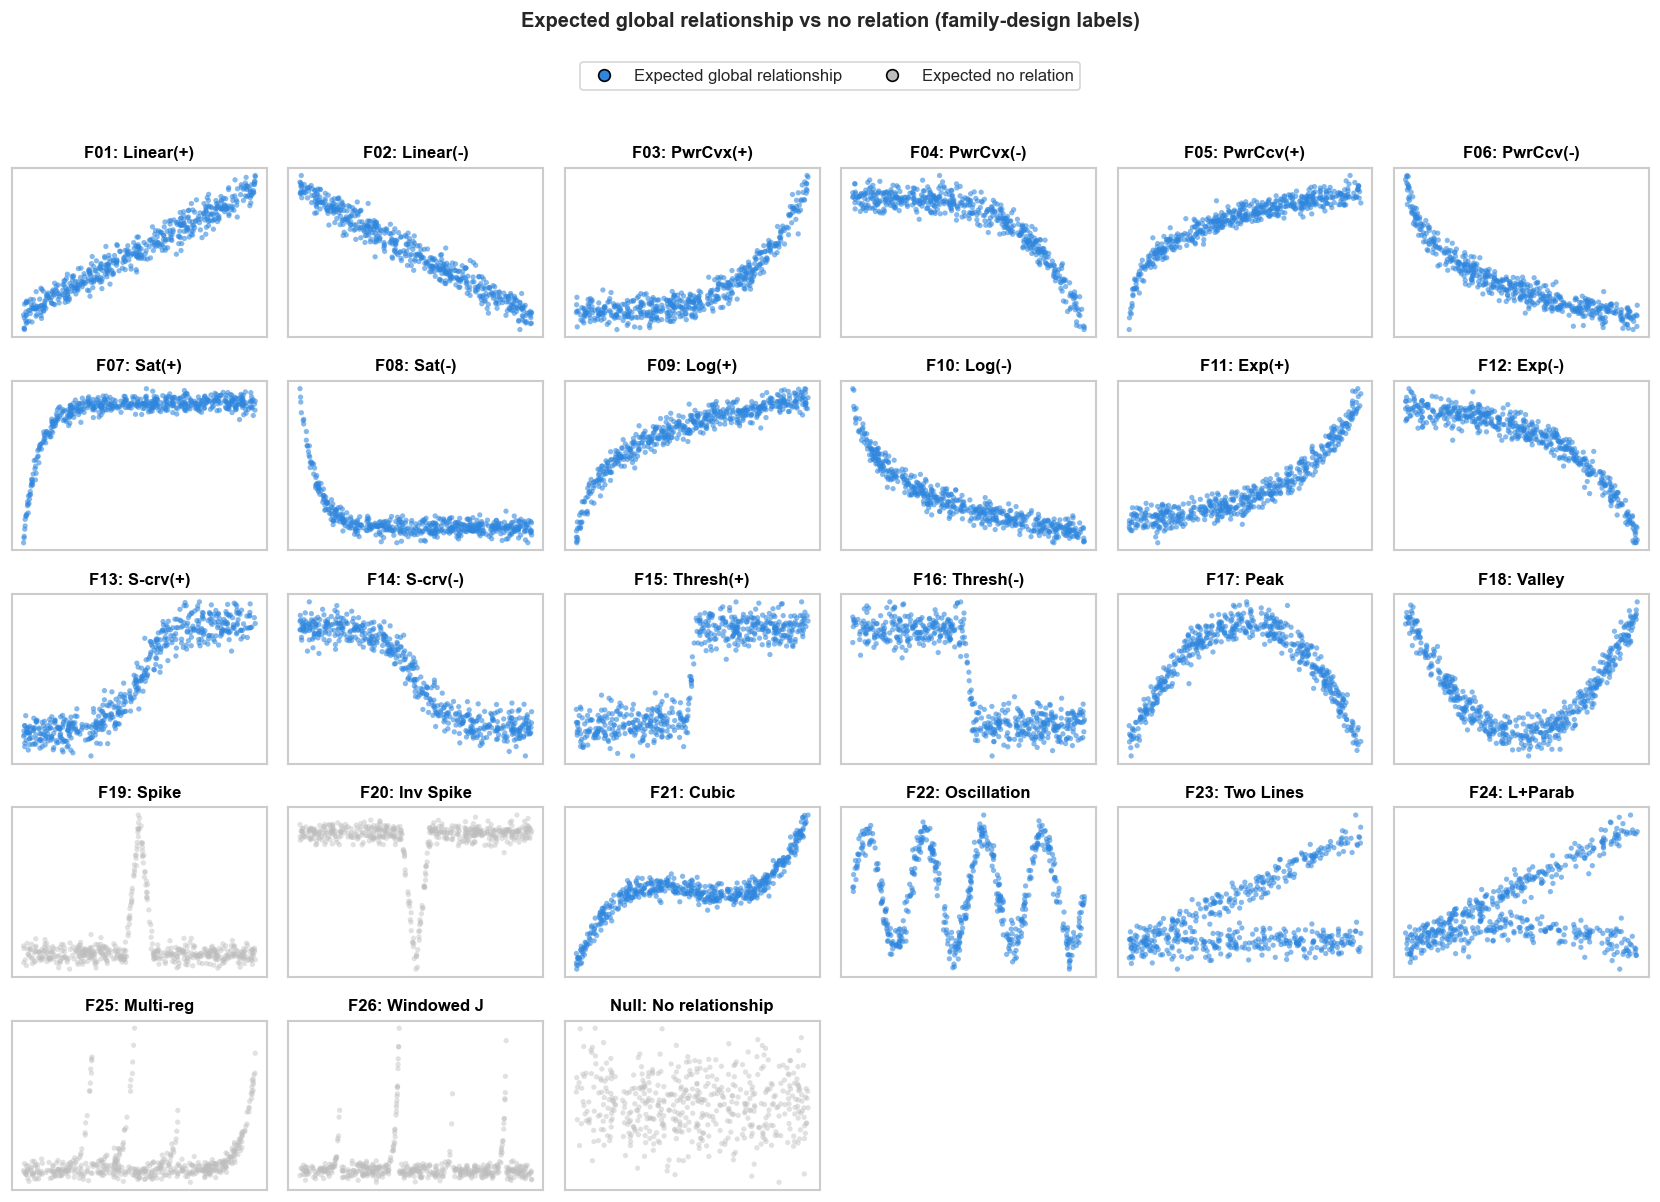

Expected no relation: ['F19', 'F20', 'F25', 'F26', 'Null']
Expected global relationship: ['F01', 'F02', 'F03', 'F04', 'F05', 'F06', 'F07', 'F08', 'F09', 'F10', 'F11', 'F12', 'F13', 'F14', 'F15', 'F16', 'F17', 'F18', 'F21', 'F22', 'F23', 'F24']


In [7]:
# ── Expected map 1: global relationship vs no relation ──
# Expected labels from family design, before applying MIC/dcor detection.
EXPECTED_NO_REL_FIDS = {'F19', 'F20', 'F25', 'F26', 'Null'}
EXPECTED_GLOBAL_FIDS = set(FAMILY_IDS_27) - EXPECTED_NO_REL_FIDS

cases_27['expected_global_label'] = np.where(
    cases_27['family_id'].isin(EXPECTED_NO_REL_FIDS),
    'Expected no relation',
    'Expected global relationship'
)

EXPECTED_GLOBAL_COLORS = {
    'Expected global relationship': '#2E86DE',
    'Expected no relation': '#BDBDBD',
}

if 'x_all' not in globals() or 'y_all' not in globals():
    pts = np.load(S1_DIR / 'scatter_points.npz')
    x_all, y_all = pts['x'], pts['y']

if 'case_idx_by_id' not in globals():
    case_idx_by_id = pd.Series(np.arange(len(cases_full)), index=cases_full['case_id']).to_dict()

fig, axes = plt.subplots(5, 6, figsize=(14, 10))
fig.suptitle('Expected global relationship vs no relation (family-design labels)',
             fontsize=12, fontweight='bold', y=1.0)

for ax, (_, row) in zip(axes.flat, cases_27.iterrows()):
    idx = case_idx_by_id.get(row['case_id'])
    label = row['expected_global_label']
    color = EXPECTED_GLOBAL_COLORS[label]
    alpha = 0.58 if label == 'Expected global relationship' else 0.45

    if idx is not None:
        ax.scatter(x_all[idx], y_all[idx], s=10, alpha=alpha,
                   color=color, edgecolors='none')

    ax.set_title(
        f"{row['family_id']}: {row['short']}",
        fontsize=10.0, fontweight='bold', color='black'
    )
    ax.set_xticks([])
    ax.set_yticks([])

for ax in axes.flat[len(cases_27):]:
    ax.set_visible(False)

handles = [Line2D([0], [0], marker='o', color='none', markerfacecolor=c,
                  markersize=7, label=k) for k, c in EXPECTED_GLOBAL_COLORS.items()]
fig.legend(handles=handles, loc='upper center', ncol=2,
           fontsize=10, frameon=True, bbox_to_anchor=(0.5, 0.965))

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

print('Expected no relation:', sorted(EXPECTED_NO_REL_FIDS))
print('Expected global relationship:', sorted(EXPECTED_GLOBAL_FIDS))


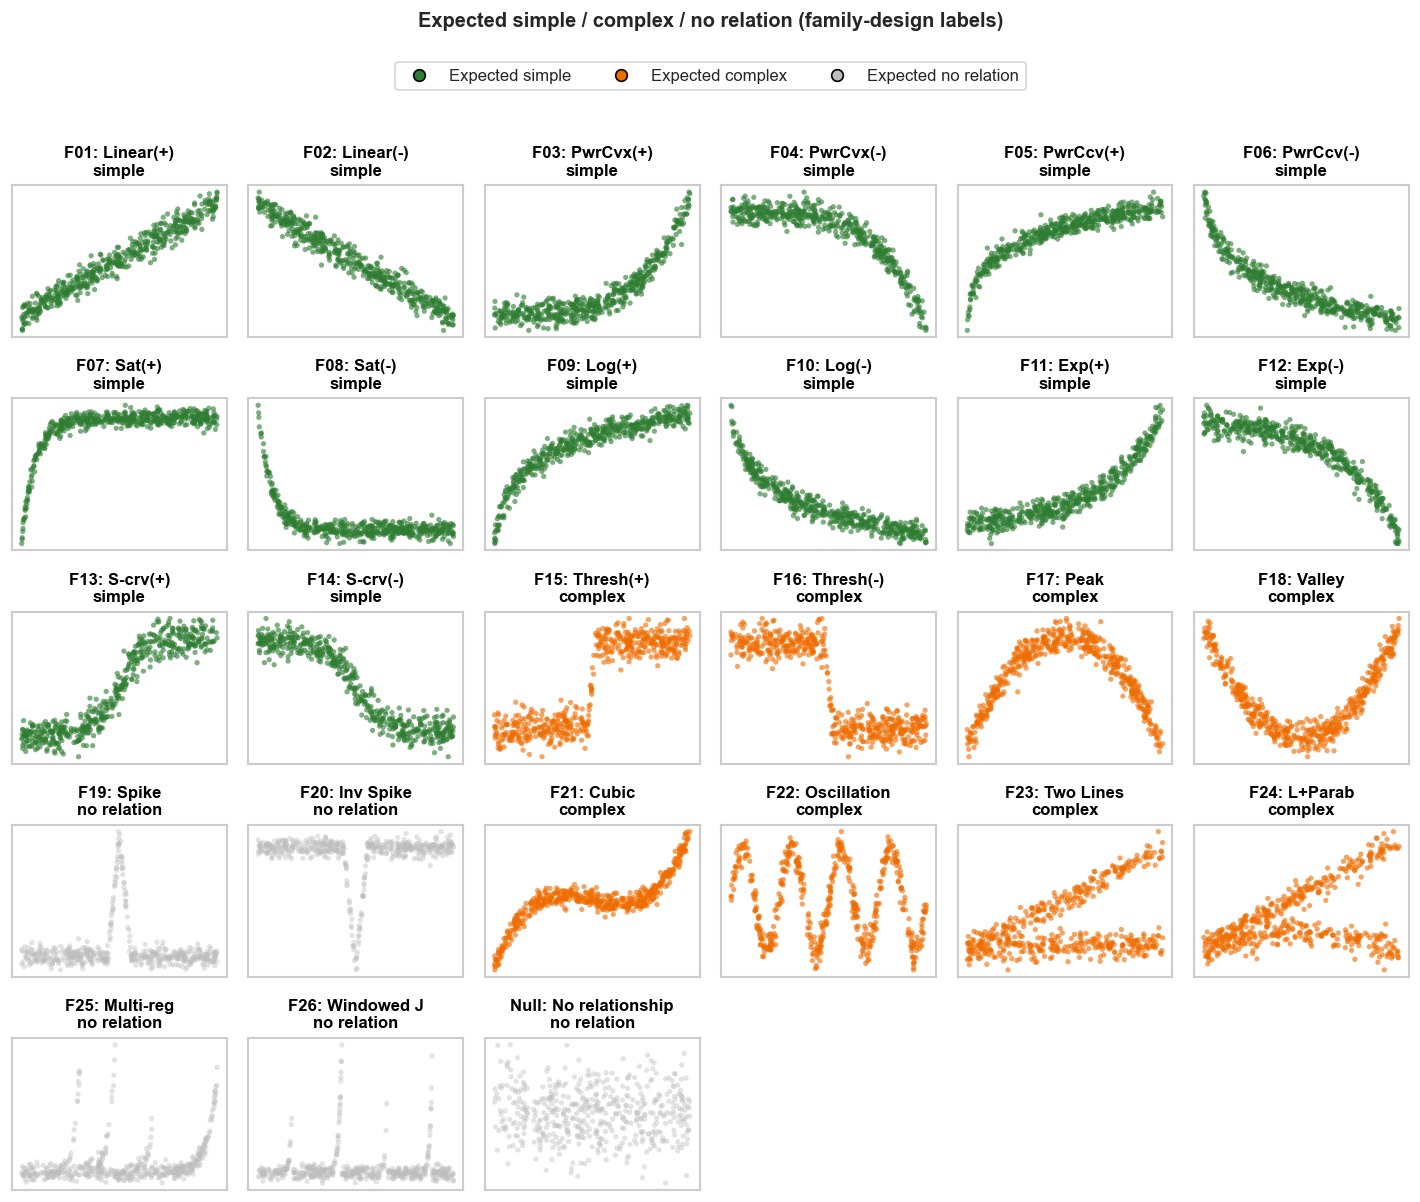

,family_id,short,expected_global_label,expected_tree_label
0,F01,Linear(+),Expected global relationship,Expected simple
1,F02,Linear(-),Expected global relationship,Expected simple
2,F03,PwrCvx(+),Expected global relationship,Expected simple
3,F04,PwrCvx(-),Expected global relationship,Expected simple
4,F05,PwrCcv(+),Expected global relationship,Expected simple
5,F06,PwrCcv(-),Expected global relationship,Expected simple
6,F07,Sat(+),Expected global relationship,Expected simple
7,F08,Sat(-),Expected global relationship,Expected simple
8,F09,Log(+),Expected global relationship,Expected simple
9,F10,Log(-),Expected global relationship,Expected simple


In [8]:
# ── Expected map 2: simple vs complex on the expected global map ──
# Simple relationship = single-regime, continuous, monotonic dominant trend.
# Complex relationship = non-monotone, multi-regime, branching, oscillation, threshold, or structural change.
EXPECTED_SIMPLE_FIDS = {
    'F01', 'F02', 'F03', 'F04', 'F05', 'F06', 'F07', 'F08',
    'F09', 'F10', 'F11', 'F12', 'F13', 'F14',
}
EXPECTED_COMPLEX_FIDS = {'F15', 'F16', 'F17', 'F18', 'F21', 'F22', 'F23', 'F24'}
EXPECTED_NO_REL_FIDS = {'F19', 'F20', 'F25', 'F26', 'Null'}

cases_27['expected_tree_label'] = np.select(
    [
        cases_27['family_id'].isin(EXPECTED_SIMPLE_FIDS),
        cases_27['family_id'].isin(EXPECTED_COMPLEX_FIDS),
        cases_27['family_id'].isin(EXPECTED_NO_REL_FIDS),
    ],
    ['Expected simple', 'Expected complex', 'Expected no relation'],
    default='Expected unassigned'
)

EXPECTED_TREE_COLORS = {
    'Expected simple': '#2E7D32',
    'Expected complex': '#EF6C00',
    'Expected no relation': '#BDBDBD',
    'Expected unassigned': '#757575',
}

if 'x_all' not in globals() or 'y_all' not in globals():
    pts = np.load(S1_DIR / 'scatter_points.npz')
    x_all, y_all = pts['x'], pts['y']

if 'case_idx_by_id' not in globals():
    case_idx_by_id = pd.Series(np.arange(len(cases_full)), index=cases_full['case_id']).to_dict()

fig, axes = plt.subplots(5, 6, figsize=(12, 10))
fig.suptitle('Expected simple / complex / no relation (family-design labels)',
             fontsize=12, fontweight='bold', y=1.0)

for ax, (_, row) in zip(axes.flat, cases_27.iterrows()):
    idx = case_idx_by_id.get(row['case_id'])
    label = row['expected_tree_label']
    color = EXPECTED_TREE_COLORS[label]
    alpha = 0.62 if label != 'Expected no relation' else 0.42

    if idx is not None:
        ax.scatter(x_all[idx], y_all[idx], s=10, alpha=alpha,
                   color=color, edgecolors='none')

    ax.set_title(
        f"{row['family_id']}: {row['short']}\n{label.replace('Expected ', '')}",
        fontsize=10, fontweight='bold', color='black'
    )
    ax.set_xticks([])
    ax.set_yticks([])

for ax in axes.flat[len(cases_27):]:
    ax.set_visible(False)

handles = [Line2D([0], [0], marker='o', color='none', markerfacecolor=c,
                  markersize=7, label=k) for k, c in EXPECTED_TREE_COLORS.items()
           if k in set(cases_27['expected_tree_label'])]
fig.legend(handles=handles, loc='upper center', ncol=3,
           fontsize=10, frameon=True, bbox_to_anchor=(0.5, 0.965))

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

display(cases_27[['family_id', 'short', 'expected_global_label', 'expected_tree_label']])


## Step 1 — Global Relationship

Same rule as `D_S2.0_analysis.ipynb` Step 1:

`MIC >= 0.8 AND distance_correlation >= 0`

Null is kept as its own baseline category.



In [9]:
# Same as D_S2.0 Step 1.
MIC_THRESH = 0.8
DCOR_THRESH = 0

# ── Step 1: global relationship classification for the 27 cases ──
cases_27['pass_MIC'] = cases_27['MIC'] >= MIC_THRESH
cases_27['pass_dcor'] = cases_27['distance_correlation'] >= DCOR_THRESH
cases_27['global_relationship'] = (
    (cases_27['family_id'] != 'Null') &
    cases_27['pass_MIC'] &
    cases_27['pass_dcor']
)

cases_27['global_label'] = np.where(
    cases_27['family_id'] == 'Null',
    'Null',
    np.where(cases_27['global_relationship'], 'Global relationship', 'No global relationship')
)

global_cases = cases_27[cases_27['global_relationship']].copy()

print('═══ Step 1: Global Relationship ═══')
print(f'Rule: MIC >= {MIC_THRESH} AND dcor >= {DCOR_THRESH}')
print(f'Global relationship: {len(global_cases)} / 26 signal families')
print()
print(cases_27['global_label'].value_counts().to_string())

display(cases_27[[
    'family_id', 'short', 'MIC', 'distance_correlation',
    'pass_MIC', 'pass_dcor', 'global_label',
]].round(3))


═══ Step 1: Global Relationship ═══
Rule: MIC >= 0.8 AND dcor >= 0
Global relationship: 17 / 26 signal families

global_label
Global relationship       17
No global relationship     9
Null                       1


,family_id,short,MIC,distance_correlation,pass_MIC,pass_dcor,global_label
0,F01,Linear(+),0.944,0.973,True,True,Global relationship
1,F02,Linear(-),0.967,0.973,True,True,Global relationship
2,F03,PwrCvx(+),0.830,0.864,True,True,Global relationship
3,F04,PwrCvx(-),0.803,0.870,True,True,Global relationship
4,F05,PwrCcv(+),0.842,0.926,True,True,Global relationship
5,F06,PwrCcv(-),0.862,0.926,True,True,Global relationship
6,F07,Sat(+),0.558,0.642,False,True,No global relationship
7,F08,Sat(-),0.550,0.617,False,True,No global relationship
8,F09,Log(+),0.887,0.921,True,True,Global relationship
9,F10,Log(-),0.883,0.926,True,True,Global relationship


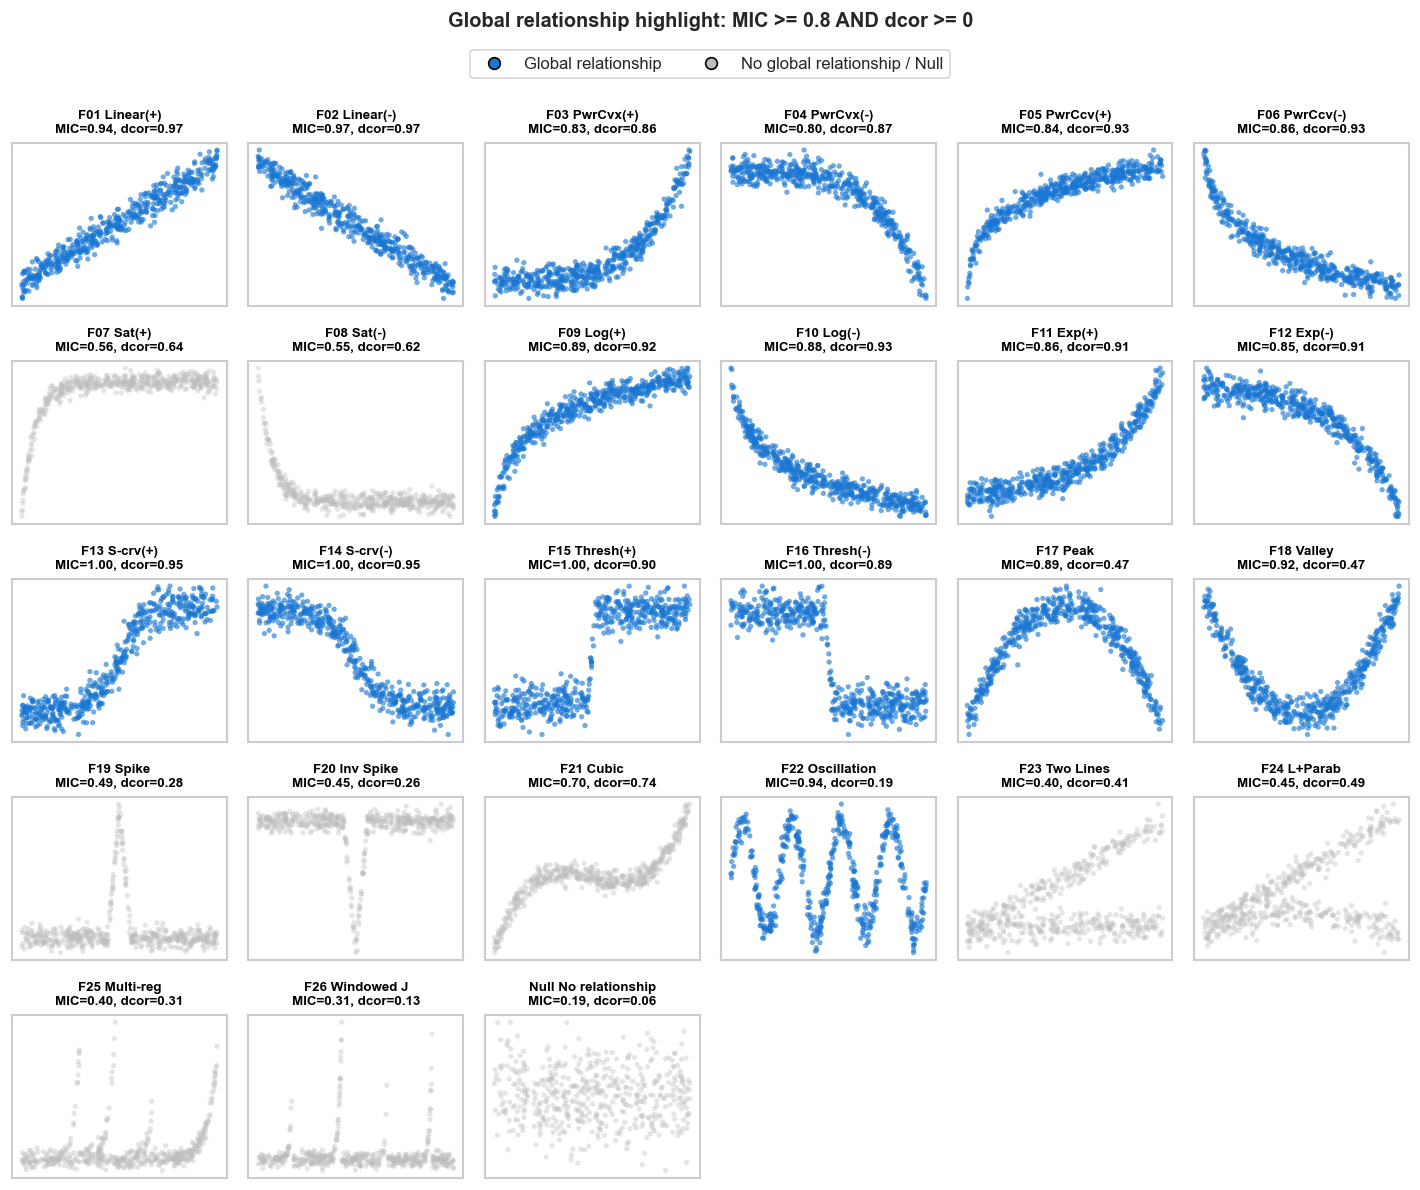

In [10]:
# ── Plot 2A: global relationship highlighted in blue ──
# Blue = passed Step 1 global relationship; gray = not global relationship, including Null.
# This cell is self-contained: it can run even if the raw 27-plot cell was not run.
GLOBAL_BLUE = '#1976D2'
GLOBAL_GRAY = '#BDBDBD'

if 'x_all' not in globals() or 'y_all' not in globals():
    pts = np.load(S1_DIR / 'scatter_points.npz')
    x_all, y_all = pts['x'], pts['y']

if 'case_idx_by_id' not in globals():
    case_idx_by_id = pd.Series(np.arange(len(cases_full)), index=cases_full['case_id']).to_dict()

fig, axes = plt.subplots(5, 6, figsize=(12, 10))
fig.suptitle(f'Global relationship highlight: MIC >= {MIC_THRESH} AND dcor >= {DCOR_THRESH}',
             fontsize=12, fontweight='bold', y=0.99)

for ax, (_, row) in zip(axes.flat, cases_27.iterrows()):
    idx = case_idx_by_id.get(row['case_id'])
    is_global = bool(row['global_relationship'])
    color = GLOBAL_BLUE if is_global else GLOBAL_GRAY
    alpha = 0.62 if is_global else 0.38

    if idx is not None:
        ax.scatter(x_all[idx], y_all[idx], s=10, alpha=alpha,
                   color=color, edgecolors='none')

    ax.set_title(
        f"{row['family_id']} {row['short']}\nMIC={row['MIC']:.2f}, dcor={row['distance_correlation']:.2f}",
        fontsize=8.0, fontweight='bold', color='black'
    )
    ax.set_xticks([])
    ax.set_yticks([])

for ax in axes.flat[len(cases_27):]:
    ax.set_visible(False)

handles = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor=GLOBAL_BLUE,
           markersize=7, label='Global relationship'),
    Line2D([0], [0], marker='o', color='none', markerfacecolor=GLOBAL_GRAY,
           markersize=7, label='No global relationship / Null'),
]
fig.legend(handles=handles, loc='upper center', ncol=2,
           fontsize=10, frameon=True, bbox_to_anchor=(0.5, 0.965))

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()




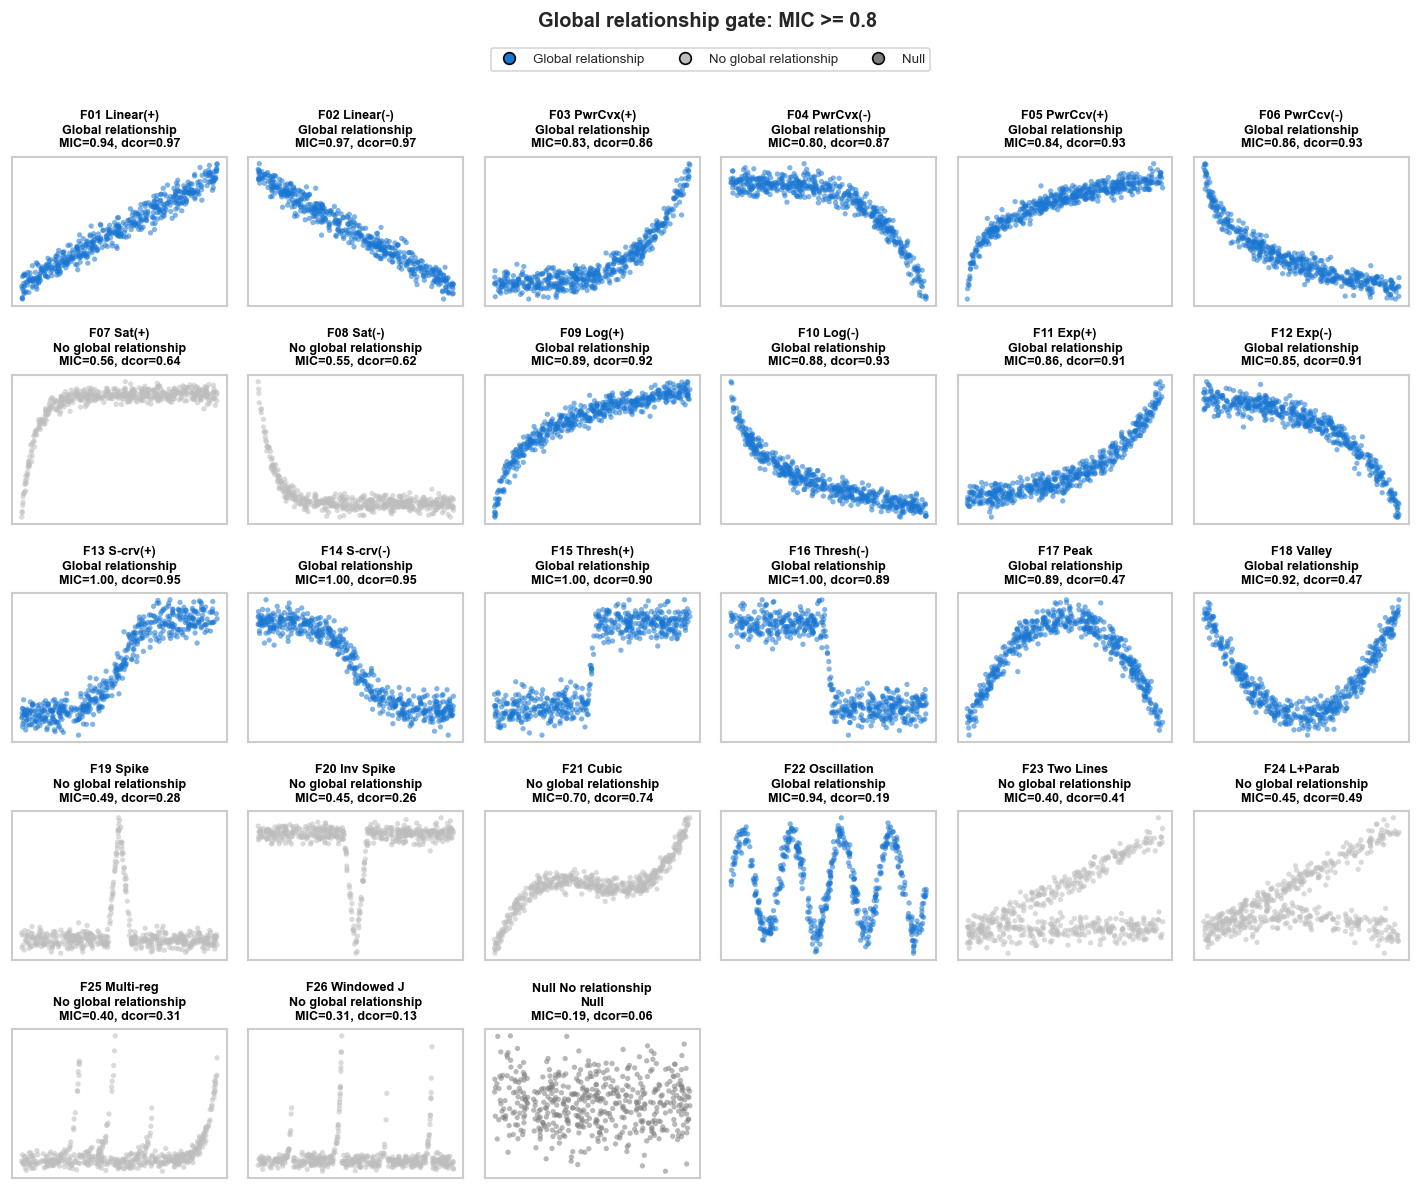

In [11]:
# ── Plot 2: global relationship pass/fail ──
# This cell is self-contained: it can run even if the raw 27-plot cell was not run.
GLOBAL_COLORS = {
    'Global relationship': '#1976D2',
    'No global relationship': '#BDBDBD',
    'Null': '#7E7E7E',
}

if 'x_all' not in globals() or 'y_all' not in globals():
    pts = np.load(S1_DIR / 'scatter_points.npz')
    x_all, y_all = pts['x'], pts['y']

if 'case_idx_by_id' not in globals():
    case_idx_by_id = pd.Series(np.arange(len(cases_full)), index=cases_full['case_id']).to_dict()

fig, axes = plt.subplots(5, 6, figsize=(12, 10))
fig.suptitle(f'Global relationship gate: MIC >= {MIC_THRESH} ',
             fontsize=12, fontweight='bold', y=0.99)

for ax, (_, row) in zip(axes.flat, cases_27.iterrows()):
    idx = case_idx_by_id.get(row['case_id'])
    color = GLOBAL_COLORS[row['global_label']]
    if idx is not None:
        ax.scatter(x_all[idx], y_all[idx], s=10, alpha=0.55,
                   color=color, edgecolors='none')
    ax.set_title(
        f"{row['family_id']} {row['short']}\n{row['global_label']}\nMIC={row['MIC']:.2f}, dcor={row['distance_correlation']:.2f}",
        fontsize=7.6, fontweight='bold', color='black'
    )
    ax.set_xticks([])
    ax.set_yticks([])

for ax in axes.flat[len(cases_27):]:
    ax.set_visible(False)

handles = [Line2D([0], [0], marker='o', color='none', markerfacecolor=c,
                  markersize=7, label=k) for k, c in GLOBAL_COLORS.items()]
fig.legend(handles=handles, loc='upper center', ncol=3,
           fontsize=8, frameon=True, bbox_to_anchor=(0.5, 0.965))

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


## Step 2 — Simple vs Complex

Run only on the cases that passed Step 1.

Same logic as `D_S2.0_analysis.ipynb`:

`MIC-r^2 < 1.0 AND |Spearman rho| >= 0.7 AND |Pearson r| >= 0.7 AND no significant E/M/L slope sign reversal`

The slope reversal prominence threshold is `0.10`.


In [12]:
# ── Step 2: Simple vs Complex for global-relationship cases ──
def compute_reversal_prominence(frame):
    e = frame['standardized_polyfit_early_slope'].to_numpy(dtype=float)
    m = frame['standardized_polyfit_middle_slope'].to_numpy(dtype=float)
    l = frame['standardized_polyfit_late_slope'].to_numpy(dtype=float)

    sign_e = np.sign(e)
    sign_m = np.sign(m)
    sign_l = np.sign(l)
    has_sign_change = ~((sign_e == sign_m) & (sign_m == sign_l))

    abs_max = np.maximum(np.maximum(np.abs(e), np.abs(m)), np.abs(l))
    abs_max = np.where(abs_max == 0, 1, abs_max)
    maj_sign = np.sign(e + m + l)

    rev_prom = np.zeros(len(frame))
    for i in range(len(frame)):
        if not has_sign_change[i] or maj_sign[i] == 0:
            continue
        slopes_i = [e[i], m[i], l[i]]
        rev_vals = [abs(s) for s in slopes_i
                    if np.sign(s) != maj_sign[i] and np.sign(s) != 0]
        if rev_vals:
            rev_prom[i] = max(rev_vals) / abs_max[i]

    return rev_prom, has_sign_change

MR_THRESH = 0.2
R_THRESH = 0.7
sc = global_cases.copy()
if len(sc) > 0:
    sc['pass_MIC_minus_r2'] = sc['MIC_minus_r2'] < MR_THRESH
    sc['pass_spearman'] = sc['spearman_rho'].abs() >= R_THRESH
    sc['pass_pearson'] = sc['pearson_r'].abs() >= R_THRESH

    rev_prom, has_sign_change = compute_reversal_prominence(sc)
    sc['has_slope_sign_change'] = has_sign_change
    sc['reversal_prominence'] = rev_prom
    sc['pass_no_reversal'] = ~(sc['has_slope_sign_change'] &
                               (sc['reversal_prominence'] >= REVERSAL_PROMINENCE))

    sc['is_simple'] = (
        sc['pass_MIC_minus_r2'] &
        sc['pass_spearman'] &
        sc['pass_pearson'] &
        sc['pass_no_reversal']
    )
else:
    sc['is_simple'] = []

cases_27 = cases_27.merge(
    sc[['case_id', 'pass_MIC_minus_r2', 'pass_spearman', 'pass_pearson',
        'has_slope_sign_change', 'reversal_prominence', 'pass_no_reversal', 'is_simple']],
    on='case_id', how='left'
)

cases_27['simple_complex_label'] = np.select(
    [
        cases_27['family_id'] == 'Null',
        ~cases_27['global_relationship'],
        cases_27['is_simple'].fillna(False),
    ],
    ['Null', 'No global relationship', 'Simple'],
    default='Complex'
)

print('═══ Step 2: Simple vs Complex ═══')
print(f'Rule: MIC-r^2 < {MR_THRESH} AND |rho| >= {R_THRESH} AND |r| >= {R_THRESH}')
print(f'      + no significant slope sign reversal (prominence >= {REVERSAL_PROMINENCE})')
print()
print(cases_27['simple_complex_label'].value_counts().to_string())

display(cases_27[[
    'family_id', 'short', 'global_label', 'MIC_minus_r2', 'spearman_rho', 'pearson_r',
    'standardized_polyfit_early_slope', 'standardized_polyfit_middle_slope',
    'standardized_polyfit_late_slope', 'reversal_prominence',
    'pass_MIC_minus_r2', 'pass_spearman', 'pass_pearson', 'pass_no_reversal',
    'simple_complex_label',
]].round(3))


═══ Step 2: Simple vs Complex ═══
Rule: MIC-r^2 < 0.2 AND |rho| >= 0.7 AND |r| >= 0.7
      + no significant slope sign reversal (prominence >= 0.1)

simple_complex_label
Simple                    12
No global relationship     9
Complex                    5
Null                       1


,family_id,short,global_label,MIC_minus_r2,spearman_rho,pearson_r,standardized_polyfit_early_slope,standardized_polyfit_middle_slope,standardized_polyfit_late_slope,reversal_prominence,pass_MIC_minus_r2,pass_spearman,pass_pearson,pass_no_reversal,simple_complex_label
0,F01,Linear(+),Global relationship,-0.010,0.978,0.977,0.861,0.794,0.814,0.000,True,True,True,True,Simple
1,F02,Linear(-),Global relationship,0.011,-0.978,-0.978,-0.892,-0.834,-0.816,0.000,True,True,True,True,Simple
2,F03,PwrCvx(+),Global relationship,0.139,0.850,0.832,0.041,0.457,1.943,0.000,True,True,True,True,Simple
3,F04,PwrCvx(-),Global relationship,0.104,-0.848,-0.836,-0.035,-0.417,-1.911,0.000,True,True,True,True,Simple
4,F05,PwrCcv(+),Global relationship,0.040,0.945,0.896,1.250,0.371,0.246,0.000,True,True,True,True,Simple
5,F06,PwrCcv(-),Global relationship,0.051,-0.955,-0.901,-1.624,-0.472,-0.273,0.000,True,True,True,True,Simple
6,F07,Sat(+),No global relationship,0.201,0.603,0.597,2.041,0.037,-0.010,NaN,NaN,NaN,NaN,NaN,No global relationship
7,F08,Sat(-),No global relationship,0.234,-0.531,-0.562,-1.673,-0.000,-0.022,NaN,NaN,NaN,NaN,NaN,No global relationship
8,F09,Log(+),Global relationship,0.096,0.952,0.889,1.702,0.502,0.308,0.000,True,True,True,True,Simple
9,F10,Log(-),Global relationship,0.069,-0.955,-0.902,-1.502,-0.435,-0.294,0.000,True,True,True,True,Simple


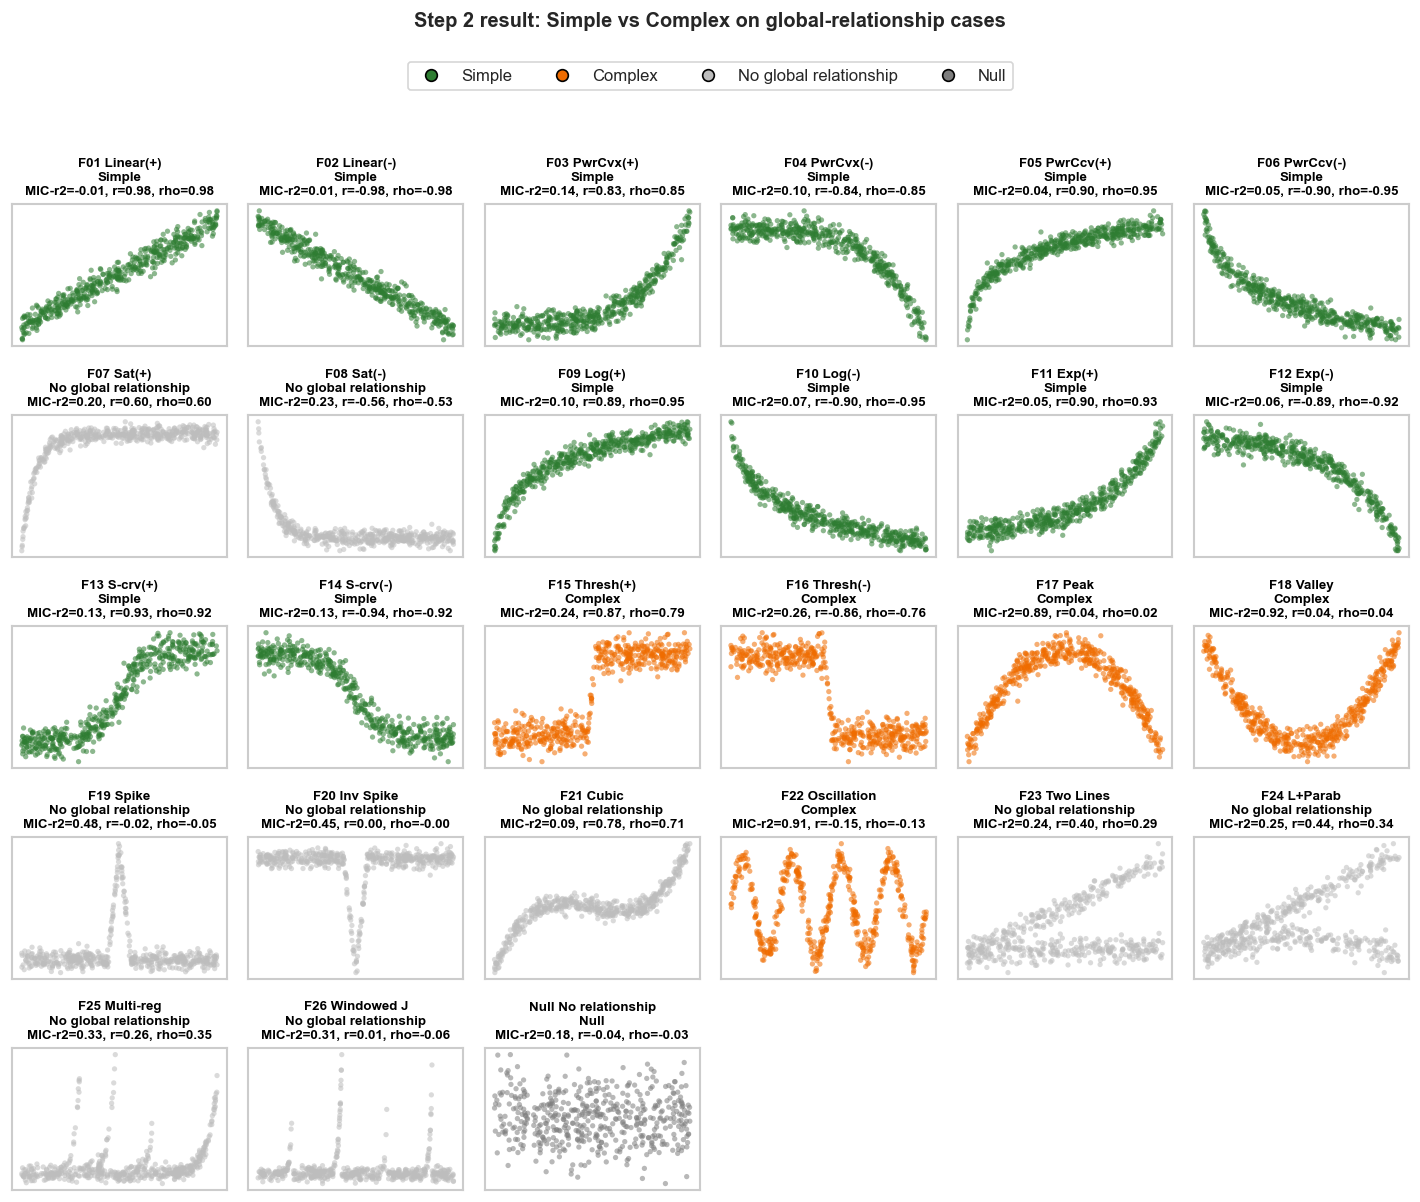

In [13]:
# ── Plot 3: Simple / Complex result ──
# This cell is self-contained: it can run even if earlier plot cells were not run.
SC_COLORS = {
    'Simple': '#2E7D32',
    'Complex': '#EF6C00',
    'No global relationship': '#BDBDBD',
    'Null': '#7E7E7E',
}

if 'x_all' not in globals() or 'y_all' not in globals():
    pts = np.load(S1_DIR / 'scatter_points.npz')
    x_all, y_all = pts['x'], pts['y']

if 'case_idx_by_id' not in globals():
    case_idx_by_id = pd.Series(np.arange(len(cases_full)), index=cases_full['case_id']).to_dict()

fig, axes = plt.subplots(5, 6, figsize=(12, 10))
fig.suptitle('Step 2 result: Simple vs Complex on global-relationship cases',
             fontsize=12, fontweight='bold', y=1.0)

for ax, (_, row) in zip(axes.flat, cases_27.iterrows()):
    idx = case_idx_by_id.get(row['case_id'])
    label = row['simple_complex_label']
    color = SC_COLORS[label]
    if idx is not None:
        ax.scatter(x_all[idx], y_all[idx], s=10, alpha=0.55,
                   color=color, edgecolors='none')
    ax.set_title(
        f"{row['family_id']} {row['short']}\n{label}\nMIC-r2={row['MIC_minus_r2']:.2f}, r={row['pearson_r']:.2f}, rho={row['spearman_rho']:.2f}",
        fontsize=8.0, fontweight='bold', color='black'
    )
    ax.set_xticks([])
    ax.set_yticks([])

for ax in axes.flat[len(cases_27):]:
    ax.set_visible(False)

handles = [Line2D([0], [0], marker='o', color='none', markerfacecolor=c,
                  markersize=7, label=k) for k, c in SC_COLORS.items()]
fig.legend(handles=handles, loc='upper center', ncol=4,
           fontsize=10, frameon=True, bbox_to_anchor=(0.5, 0.965))

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


## Step 3 — Direction

Direction is determined by the sign of Pearson r.

Only applies to Simple cases from Step 2.

In [14]:
# ── Step 3: Direction (sign of Pearson r) ──
simple_cases_27 = cases_27[cases_27['simple_complex_label'] == 'Simple'].copy()

simple_cases_27['direction_tree'] = np.where(
    simple_cases_27['pearson_r'] > 0, 'Positive', 'Negative'
)

print(f'═══ Step 3: Direction (sign of Pearson r) ═══')
print(f'Simple cases: {len(simple_cases_27)}')
print()
print(simple_cases_27['direction_tree'].value_counts().to_string())
print()

display(simple_cases_27[['family_id', 'short', 'pearson_r', 'direction_tree']].round(3))

═══ Step 3: Direction (sign of Pearson r) ═══
Simple cases: 12

direction_tree
Positive    6
Negative    6



,family_id,short,pearson_r,direction_tree
0,F01,Linear(+),0.977,Positive
1,F02,Linear(-),-0.978,Negative
2,F03,PwrCvx(+),0.832,Positive
3,F04,PwrCvx(-),-0.836,Negative
4,F05,PwrCcv(+),0.896,Positive
5,F06,PwrCcv(-),-0.901,Negative
8,F09,Log(+),0.889,Positive
9,F10,Log(-),-0.902,Negative
10,F11,Exp(+),0.896,Positive
11,F12,Exp(-),-0.890,Negative


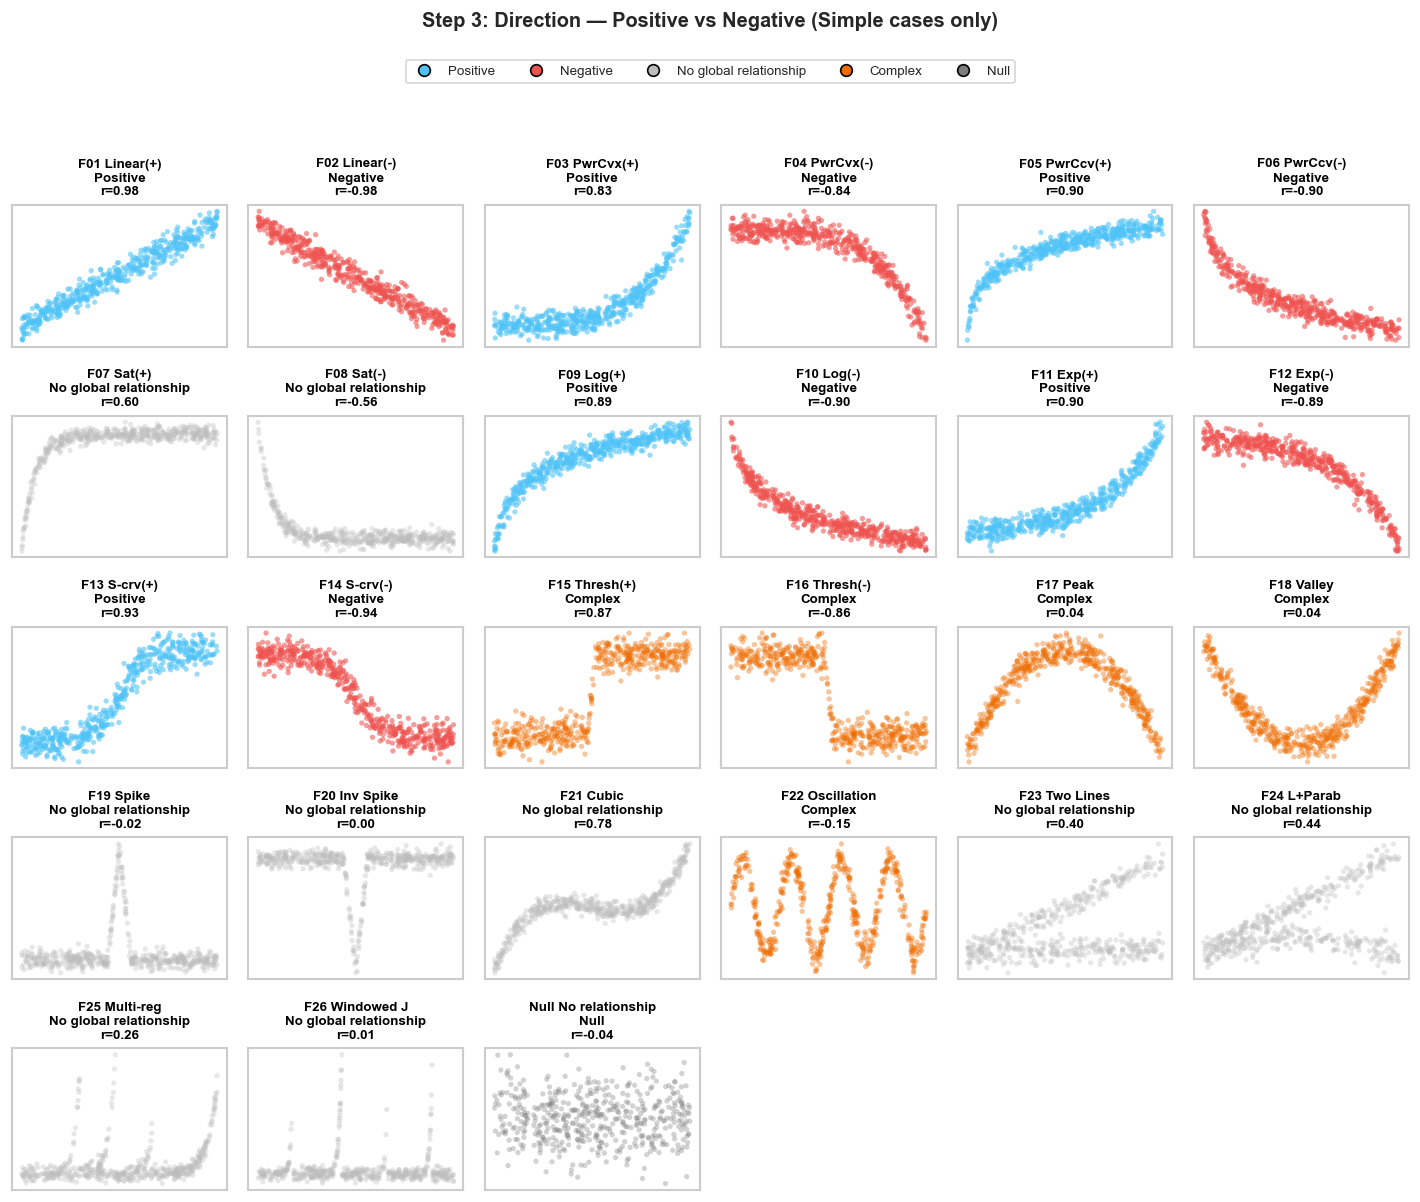

In [15]:
# ── Plot Step 3: Direction on 27-case grid ──
DIR_COLORS = {
    'Positive': '#4FC3F7',
    'Negative': '#EF5350',
    'No global relationship': '#BDBDBD',
    'Complex': '#EF6C00',
    'Null': '#7E7E7E',
}

# Merge direction back to cases_27
cases_27 = cases_27.drop(columns=['direction_tree'], errors='ignore')
cases_27 = cases_27.merge(
    simple_cases_27[['case_id', 'direction_tree']], on='case_id', how='left'
)

if 'x_all' not in globals() or 'y_all' not in globals():
    pts = np.load(S1_DIR / 'scatter_points.npz')
    x_all, y_all = pts['x'], pts['y']

if 'case_idx_by_id' not in globals():
    case_idx_by_id = pd.Series(np.arange(len(cases_full)), index=cases_full['case_id']).to_dict()

fig, axes = plt.subplots(5, 6, figsize=(12, 10))
fig.suptitle('Step 3: Direction — Positive vs Negative (Simple cases only)',
             fontsize=12, fontweight='bold', y=1.0)

for ax, (_, row) in zip(axes.flat, cases_27.iterrows()):
    idx = case_idx_by_id.get(row['case_id'])
    if row['simple_complex_label'] == 'Simple':
        label = row['direction_tree']
        color = DIR_COLORS[label]
        alpha = 0.58
    elif row['simple_complex_label'] == 'Complex':
        label = 'Complex'
        color = DIR_COLORS['Complex']
        alpha = 0.40
    elif row['family_id'] == 'Null':
        label = 'Null'
        color = DIR_COLORS['Null']
        alpha = 0.35
    else:
        label = 'No global relationship'
        color = DIR_COLORS['No global relationship']
        alpha = 0.35

    if idx is not None:
        ax.scatter(x_all[idx], y_all[idx], s=10, alpha=alpha,
                   color=color, edgecolors='none')

    ax.set_title(
        f"{row['family_id']} {row['short']}\n{label}\nr={row['pearson_r']:.2f}",
        fontsize=8.0, fontweight='bold', color='black'
    )
    ax.set_xticks([])
    ax.set_yticks([])

for ax in axes.flat[len(cases_27):]:
    ax.set_visible(False)

handles = [Line2D([0], [0], marker='o', color='none', markerfacecolor=c,
                  markersize=7, label=k) for k, c in DIR_COLORS.items()]
fig.legend(handles=handles, loc='upper center', ncol=len(DIR_COLORS),
           fontsize=8, frameon=True, bbox_to_anchor=(0.5, 0.965))

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

## Step 4 — Monotonicity

Monotonicity is classified by |Spearman rho|:
- **Strong**: |rho| >= 0.9
- **Med**: |rho| < 0.9

In [16]:
# ── Step 4: Monotonicity (|rho| level) ──
MONO_STRONG = 0.9

simple_cases_27['monotonicity_tree'] = np.where(
    simple_cases_27['spearman_rho'].abs() >= MONO_STRONG, 'Strong', 'Med'
)

print(f'═══ Step 4: Monotonicity (|ρ| ≥ {MONO_STRONG} → Strong) ═══')
print()
print(simple_cases_27['monotonicity_tree'].value_counts().to_string())
print()

display(simple_cases_27[['family_id', 'short', 'spearman_rho', 'direction_tree', 'monotonicity_tree']].round(3))

═══ Step 4: Monotonicity (|ρ| ≥ 0.9 → Strong) ═══

monotonicity_tree
Strong    10
Med        2



,family_id,short,spearman_rho,direction_tree,monotonicity_tree
0,F01,Linear(+),0.978,Positive,Strong
1,F02,Linear(-),-0.978,Negative,Strong
2,F03,PwrCvx(+),0.850,Positive,Med
3,F04,PwrCvx(-),-0.848,Negative,Med
4,F05,PwrCcv(+),0.945,Positive,Strong
5,F06,PwrCcv(-),-0.955,Negative,Strong
8,F09,Log(+),0.952,Positive,Strong
9,F10,Log(-),-0.955,Negative,Strong
10,F11,Exp(+),0.932,Positive,Strong
11,F12,Exp(-),-0.923,Negative,Strong


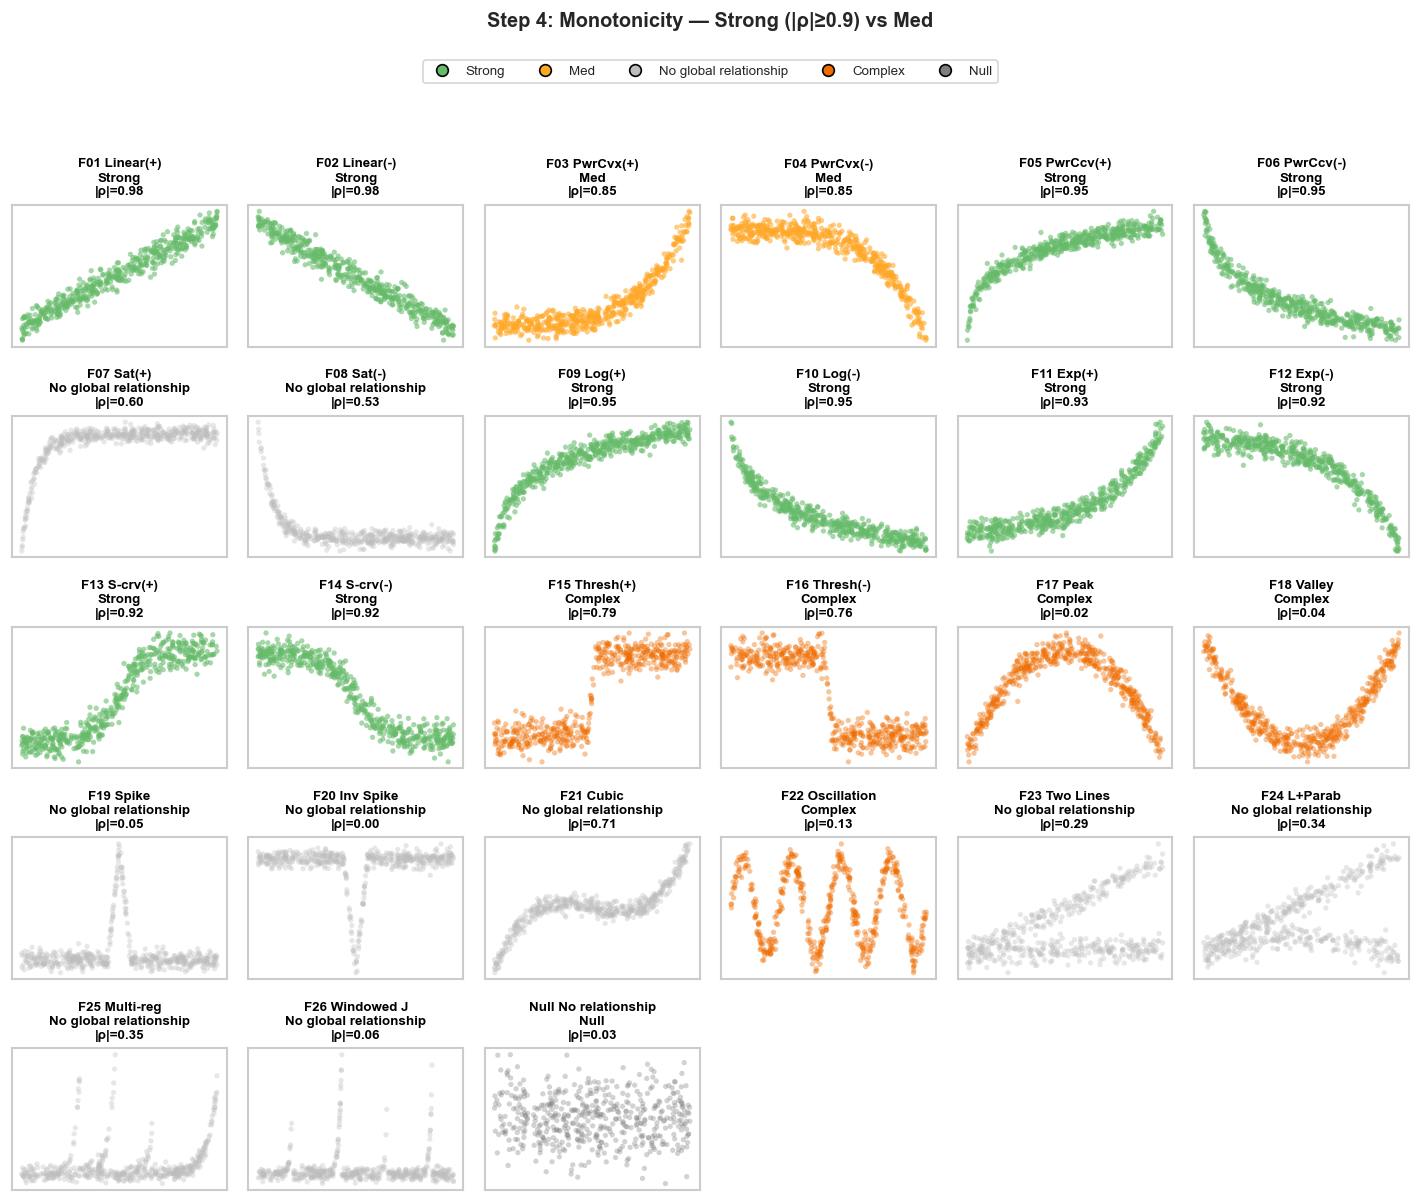

In [17]:
# ── Plot Step 4: Monotonicity on 27-case grid ──
MONO_COLORS = {
    'Strong': '#66BB6A',
    'Med': '#FFA726',
    'No global relationship': '#BDBDBD',
    'Complex': '#EF6C00',
    'Null': '#7E7E7E',
}

cases_27 = cases_27.drop(columns=['monotonicity_tree'], errors='ignore')
cases_27 = cases_27.merge(
    simple_cases_27[['case_id', 'monotonicity_tree']], on='case_id', how='left'
)

fig, axes = plt.subplots(5, 6, figsize=(12, 10))
fig.suptitle(f'Step 4: Monotonicity — Strong (|ρ|≥{MONO_STRONG}) vs Med',
             fontsize=12, fontweight='bold', y=1.0)

for ax, (_, row) in zip(axes.flat, cases_27.iterrows()):
    idx = case_idx_by_id.get(row['case_id'])
    if row['simple_complex_label'] == 'Simple':
        label = row['monotonicity_tree']
        color = MONO_COLORS[label]
        alpha = 0.58
    elif row['simple_complex_label'] == 'Complex':
        label = 'Complex'
        color = MONO_COLORS['Complex']
        alpha = 0.40
    elif row['family_id'] == 'Null':
        label = 'Null'
        color = MONO_COLORS['Null']
        alpha = 0.35
    else:
        label = 'No global relationship'
        color = MONO_COLORS['No global relationship']
        alpha = 0.35

    if idx is not None:
        ax.scatter(x_all[idx], y_all[idx], s=10, alpha=alpha,
                   color=color, edgecolors='none')

    ax.set_title(
        f"{row['family_id']} {row['short']}\n{label}\n|ρ|={abs(row['spearman_rho']):.2f}",
        fontsize=8.0, fontweight='bold', color='black'
    )
    ax.set_xticks([])
    ax.set_yticks([])

for ax in axes.flat[len(cases_27):]:
    ax.set_visible(False)

handles = [Line2D([0], [0], marker='o', color='none', markerfacecolor=c,
                  markersize=7, label=k) for k, c in MONO_COLORS.items()]
fig.legend(handles=handles, loc='upper center', ncol=len(MONO_COLORS),
           fontsize=8, frameon=True, bbox_to_anchor=(0.5, 0.965))

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

## Step 5 — Linearity + Line Detection

Linearity check: |Pearson r| ≥ 0.9.

Full Line detection: Strong monotonicity + |r| ≥ 0.9 + slope_span < 0.20 (E/M/L slopes uniform).

Cases passing all three conditions are true Lines; others with |r| ≥ 0.9 but non-uniform slopes are curved.

In [18]:
# ── Step 5: Linearity + Line Detection ──
LIN_STRONG = 0.9
LINE_SPAN_TOL = 0.20

simple_cases_27['linearity_tree'] = np.where(
    simple_cases_27['pearson_r'].abs() >= LIN_STRONG, 'High |r|', 'Med |r|'
)

# Compute direction-aware slopes and span for Line detection
E_raw = simple_cases_27['standardized_polyfit_early_slope'].values
M_raw = simple_cases_27['standardized_polyfit_middle_slope'].values
L_raw = simple_cases_27['standardized_polyfit_late_slope'].values

scale = np.maximum(np.maximum(np.abs(E_raw), np.abs(M_raw)), np.abs(L_raw))
scale = np.where(scale == 0, 1, scale)
e_n, m_n, l_n = E_raw / scale, M_raw / scale, L_raw / scale

dsign = np.where(simple_cases_27['pearson_r'].values > 0, 1, -1)
e_d = e_n * dsign
m_d = m_n * dsign
l_d = l_n * dsign

simple_cases_27['e_d'] = e_d
simple_cases_27['m_d'] = m_d
simple_cases_27['l_d'] = l_d

slopes = np.column_stack([e_d, m_d, l_d])
slope_span = slopes.max(axis=1) - slopes.min(axis=1)
simple_cases_27['slope_span'] = slope_span

# Line = Strong mono + High |r| + uniform slopes
simple_cases_27['is_line'] = (
    (simple_cases_27['monotonicity_tree'] == 'Strong') &
    (simple_cases_27['linearity_tree'] == 'High |r|') &
    (simple_cases_27['slope_span'] < LINE_SPAN_TOL)
)

print(f'═══ Step 5: Linearity + Line Detection ═══')
print(f'|r| ≥ {LIN_STRONG} → High |r|')
print(f'Line = Strong mono + High |r| + slope_span < {LINE_SPAN_TOL}')
print()
print(f'High |r|: {(simple_cases_27["linearity_tree"] == "High |r|").sum()} / {len(simple_cases_27)}')
print(f'True Line (+ Strong mono + uniform slopes): {simple_cases_27["is_line"].sum()} / {len(simple_cases_27)}')
print()

display(simple_cases_27[[
    'family_id', 'short', 'direction_tree', 'monotonicity_tree',
    'linearity_tree', 'pearson_r', 'spearman_rho',
    'e_d', 'm_d', 'l_d', 'slope_span', 'is_line',
]].round(3))

═══ Step 5: Linearity + Line Detection ═══
|r| ≥ 0.9 → High |r|
Line = Strong mono + High |r| + slope_span < 0.2

High |r|: 6 / 12
True Line (+ Strong mono + uniform slopes): 2 / 12



,family_id,short,direction_tree,monotonicity_tree,linearity_tree,pearson_r,spearman_rho,e_d,m_d,l_d,slope_span,is_line
0,F01,Linear(+),Positive,Strong,High |r|,0.977,0.978,1.000,0.922,0.946,0.078,True
1,F02,Linear(-),Negative,Strong,High |r|,-0.978,-0.978,1.000,0.935,0.914,0.086,True
2,F03,PwrCvx(+),Positive,Med,Med |r|,0.832,0.850,0.021,0.235,1.000,0.979,False
3,F04,PwrCvx(-),Negative,Med,Med |r|,-0.836,-0.848,0.018,0.218,1.000,0.982,False
4,F05,PwrCcv(+),Positive,Strong,Med |r|,0.896,0.945,1.000,0.297,0.197,0.803,False
5,F06,PwrCcv(-),Negative,Strong,High |r|,-0.901,-0.955,1.000,0.291,0.168,0.832,False
8,F09,Log(+),Positive,Strong,Med |r|,0.889,0.952,1.000,0.295,0.181,0.819,False
9,F10,Log(-),Negative,Strong,High |r|,-0.902,-0.955,1.000,0.290,0.196,0.804,False
10,F11,Exp(+),Positive,Strong,Med |r|,0.896,0.932,0.151,0.317,1.000,0.849,False
11,F12,Exp(-),Negative,Strong,Med |r|,-0.890,-0.923,0.102,0.303,1.000,0.898,False


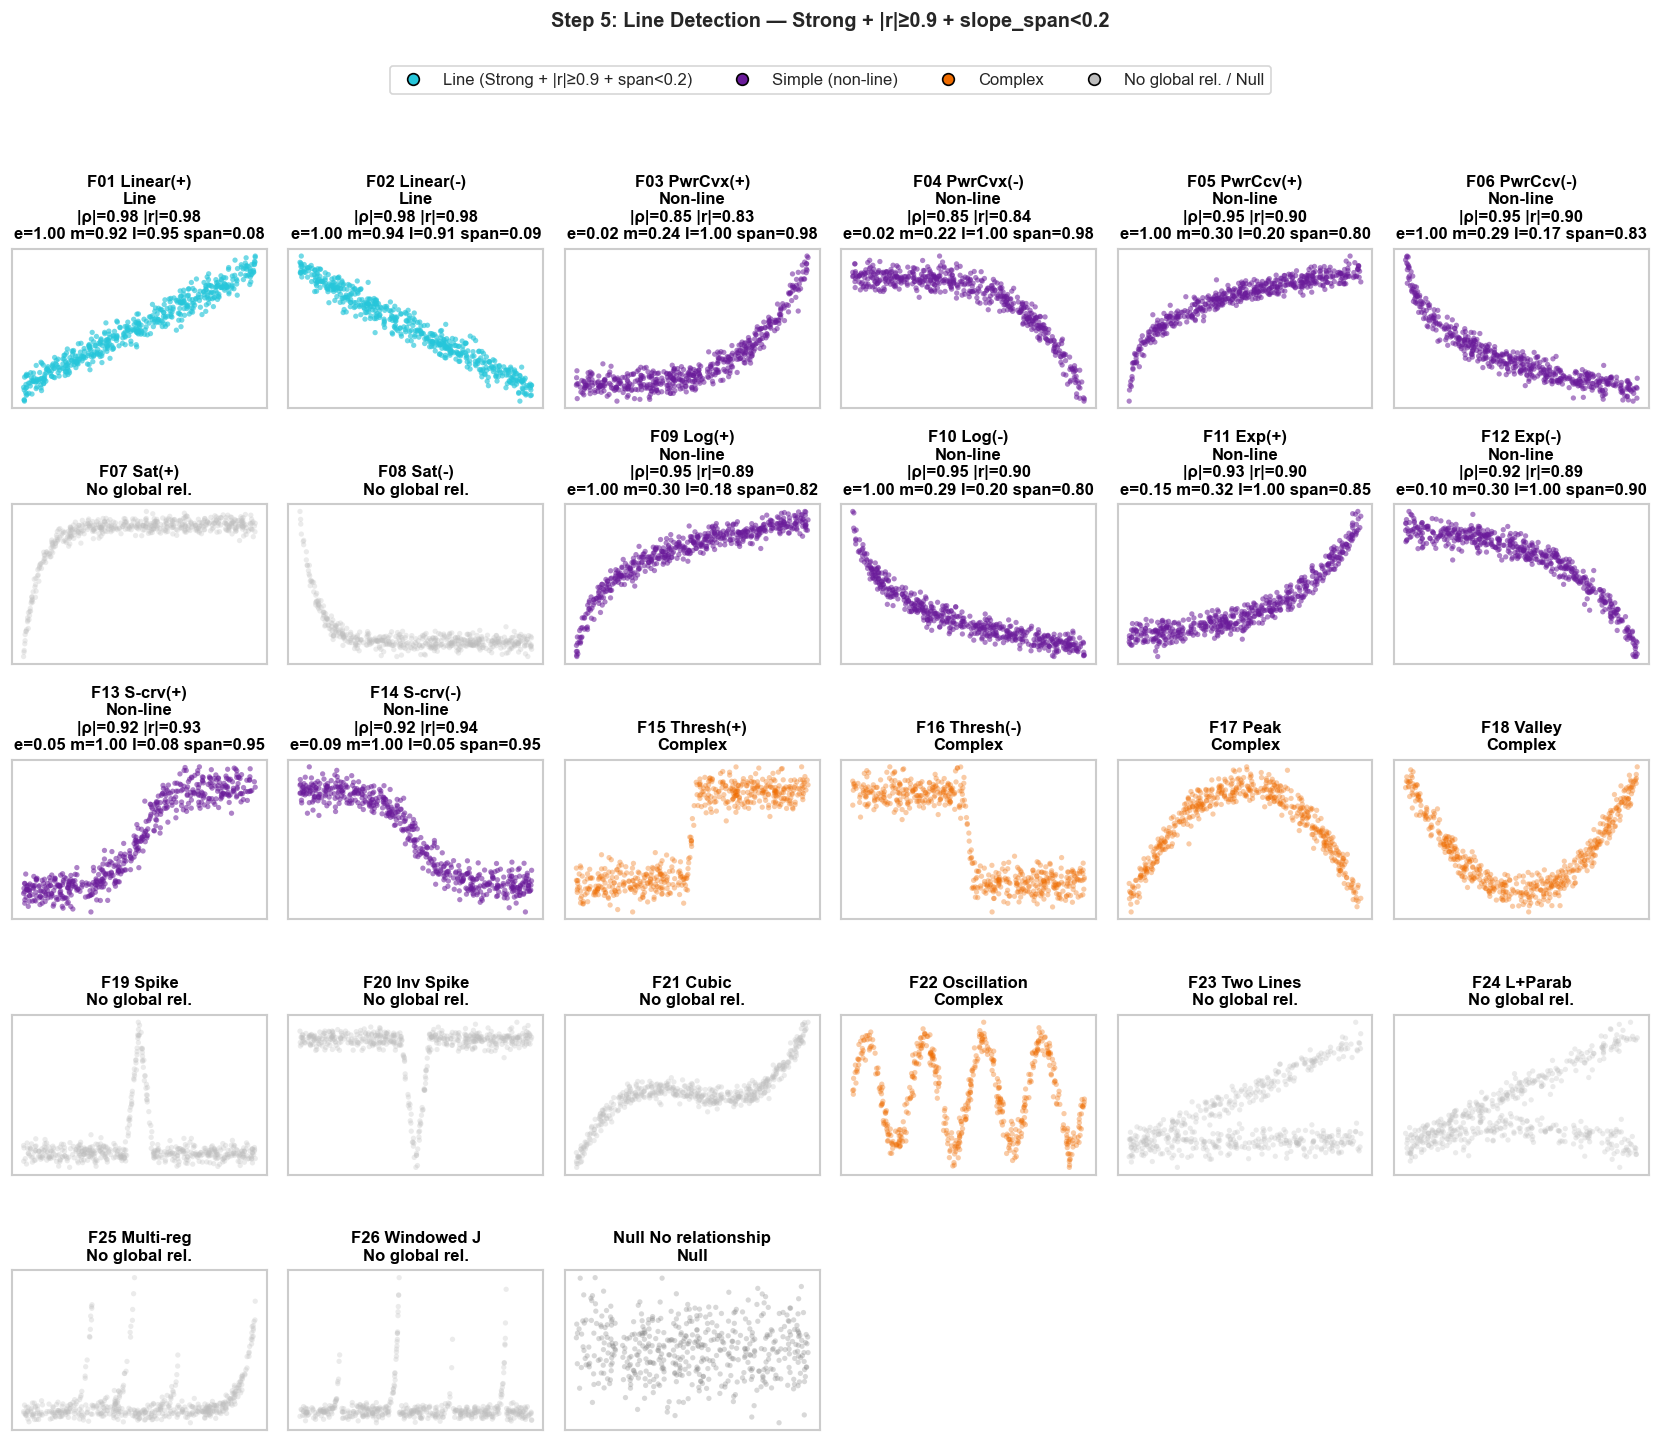

In [19]:
# ── Plot Step 5: Linearity + Line Detection on 27-case grid ──
LINE_COLOR = '#26C6DA'
NONLINE_SIMPLE_COLOR = '#6A1B9A'
BG_COLORS = {
    'No global relationship': '#BDBDBD',
    'Complex': '#EF6C00',
    'Null': '#7E7E7E',
}

cases_27 = cases_27.drop(columns=['linearity_tree', 'is_line', 'e_d', 'm_d', 'l_d', 'slope_span'], errors='ignore')
cases_27 = cases_27.merge(
    simple_cases_27[['case_id', 'linearity_tree', 'is_line', 'e_d', 'm_d', 'l_d', 'slope_span']],
    on='case_id', how='left'
)

if 'x_all' not in globals() or 'y_all' not in globals():
    pts = np.load(S1_DIR / 'scatter_points.npz')
    x_all, y_all = pts['x'], pts['y']

if 'case_idx_by_id' not in globals():
    case_idx_by_id = pd.Series(np.arange(len(cases_full)), index=cases_full['case_id']).to_dict()

fig, axes = plt.subplots(5, 6, figsize=(14, 12))
fig.suptitle(f'Step 5: Line Detection — Strong + |r|≥{LIN_STRONG} + slope_span<{LINE_SPAN_TOL}',
             fontsize=12, fontweight='bold', y=1.0)

for ax, (_, row) in zip(axes.flat, cases_27.iterrows()):
    idx = case_idx_by_id.get(row['case_id'])

    if row['simple_complex_label'] == 'Simple':
        if row['is_line'] == True:
            label = 'Line'
            color = LINE_COLOR
            alpha = 0.65
        else:
            label = 'Non-line'
            color = NONLINE_SIMPLE_COLOR
            alpha = 0.55
    elif row['simple_complex_label'] == 'Complex':
        label = 'Complex'
        color = BG_COLORS['Complex']
        alpha = 0.35
    elif row['family_id'] == 'Null':
        label = 'Null'
        color = BG_COLORS['Null']
        alpha = 0.30
    else:
        label = 'No global rel.'
        color = BG_COLORS['No global relationship']
        alpha = 0.30

    if idx is not None:
        ax.scatter(x_all[idx], y_all[idx], s=10, alpha=alpha,
                   color=color, edgecolors='none')

    if row['simple_complex_label'] == 'Simple':
        ax.set_title(
            f"{row['family_id']} {row['short']}\n{label}\n"
            f"|ρ|={abs(row['spearman_rho']):.2f} |r|={abs(row['pearson_r']):.2f}\n"
            f"e={row['e_d']:.2f} m={row['m_d']:.2f} l={row['l_d']:.2f} span={row['slope_span']:.2f}",
            fontsize=10, fontweight='bold', color='black'
        )
    else:
        ax.set_title(
            f"{row['family_id']} {row['short']}\n{label}",
            fontsize=10, fontweight='bold', color='black'
        )
    ax.set_xticks([])
    ax.set_yticks([])

for ax in axes.flat[len(cases_27):]:
    ax.set_visible(False)

handles = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor=LINE_COLOR,
           markersize=7, label=f'Line (Strong + |r|≥{LIN_STRONG} + span<{LINE_SPAN_TOL})'),
    Line2D([0], [0], marker='o', color='none', markerfacecolor=NONLINE_SIMPLE_COLOR,
           markersize=7, label='Simple (non-line)'),
    Line2D([0], [0], marker='o', color='none', markerfacecolor=BG_COLORS['Complex'],
           markersize=7, label='Complex'),
    Line2D([0], [0], marker='o', color='none', markerfacecolor=BG_COLORS['No global relationship'],
           markersize=7, label='No global rel. / Null'),
]
fig.legend(handles=handles, loc='upper center', ncol=4,
           fontsize=10, frameon=True, bbox_to_anchor=(0.5, 0.968))

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

## Step 6 — Curvature Classification

For non-Line Simple cases, classify curvature by overall span of direction-aware E/M/L slopes + non-violation monotonicity:
- Convex: overall increasing (l_d − e_d > span threshold), middle does not violate trend
- Concave: overall decreasing (e_d − l_d > span threshold), middle does not violate trend
- Inflected: middle is peak (m_d > e_d + margin AND m_d > l_d + margin)
- Weak/Uncertain: V_s too low or no clear pattern

In [20]:
# ── Step 6: Curvature Classification ──
# Slopes (e_d, m_d, l_d, slope_span) already computed in Step 5.
CURVE_VS_MIN      = 0.35
CURVE_SPAN_THRESH = 0.20
CURVE_NONVIOL_TOL = 0.05
CURVE_INFLECT_MG  = 0.10

e_d = simple_cases_27['e_d'].values
m_d = simple_cases_27['m_d'].values
l_d = simple_cases_27['l_d'].values

# V_s for curvature gate
slopes = np.column_stack([e_d, m_d, l_d])
slope_mean = np.abs(slopes.mean(axis=1))
slope_sd = slopes.std(axis=1, ddof=0)
V_s = slope_sd / (slope_mean + 1e-8)
simple_cases_27['slope_Vs'] = V_s

# Shape classification
shape = np.full(len(simple_cases_27), 'Weak/Uncertain', dtype=object)
shape[simple_cases_27['is_line'].values] = 'Line'

curve_ready = (shape == 'Weak/Uncertain') & (V_s >= CURVE_VS_MIN)
tol = CURVE_NONVIOL_TOL
mg = CURVE_INFLECT_MG

is_concave = (curve_ready
    & (e_d - l_d > CURVE_SPAN_THRESH)
    & (m_d <= e_d + tol)
    & (m_d >= l_d - tol))
shape[is_concave] = 'Concave'

is_convex = (curve_ready
    & (l_d - e_d > CURVE_SPAN_THRESH)
    & (m_d >= e_d - tol)
    & (m_d <= l_d + tol))
shape[is_convex] = 'Convex'

is_inflected = (curve_ready
    & (shape == 'Weak/Uncertain')
    & (m_d > e_d + mg)
    & (m_d > l_d + mg))
shape[is_inflected] = 'Inflected'

simple_cases_27['shape_tree'] = shape

print(f'═══ Step 6: Curvature Classification ═══')
print(f'Concave:   e_d - l_d > {CURVE_SPAN_THRESH}, m_d ∈ [l_d-{tol}, e_d+{tol}]')
print(f'Convex:    l_d - e_d > {CURVE_SPAN_THRESH}, m_d ∈ [e_d-{tol}, l_d+{tol}]')
print(f'Inflected: m_d > e_d+{mg} AND m_d > l_d+{mg}')
print(f'Gate: V_s ≥ {CURVE_VS_MIN}')
print()
print(simple_cases_27['shape_tree'].value_counts().to_string())
print()

display(simple_cases_27[[
    'family_id', 'short', 'direction_tree', 'monotonicity_tree',
    'is_line', 'shape_tree',
    'e_d', 'm_d', 'l_d', 'slope_span', 'slope_Vs',
]].round(3))

═══ Step 6: Curvature Classification ═══
Concave:   e_d - l_d > 0.2, m_d ∈ [l_d-0.05, e_d+0.05]
Convex:    l_d - e_d > 0.2, m_d ∈ [e_d-0.05, l_d+0.05]
Inflected: m_d > e_d+0.1 AND m_d > l_d+0.1
Gate: V_s ≥ 0.35

shape_tree
Convex       4
Concave      4
Line         2
Inflected    2



,family_id,short,direction_tree,monotonicity_tree,is_line,shape_tree,e_d,m_d,l_d,slope_span,slope_Vs
0,F01,Linear(+),Positive,Strong,True,Line,1.000,0.922,0.946,0.078,0.034
1,F02,Linear(-),Negative,Strong,True,Line,1.000,0.935,0.914,0.086,0.038
2,F03,PwrCvx(+),Positive,Med,False,Convex,0.021,0.235,1.000,0.979,1.003
3,F04,PwrCvx(-),Negative,Med,False,Convex,0.018,0.218,1.000,0.982,1.028
4,F05,PwrCcv(+),Positive,Strong,False,Concave,1.000,0.297,0.197,0.803,0.717
5,F06,PwrCcv(-),Negative,Strong,False,Concave,1.000,0.291,0.168,0.832,0.754
8,F09,Log(+),Positive,Strong,False,Concave,1.000,0.295,0.181,0.819,0.736
9,F10,Log(-),Negative,Strong,False,Concave,1.000,0.290,0.196,0.804,0.725
10,F11,Exp(+),Positive,Strong,False,Convex,0.151,0.317,1.000,0.849,0.751
11,F12,Exp(-),Negative,Strong,False,Convex,0.102,0.303,1.000,0.898,0.822


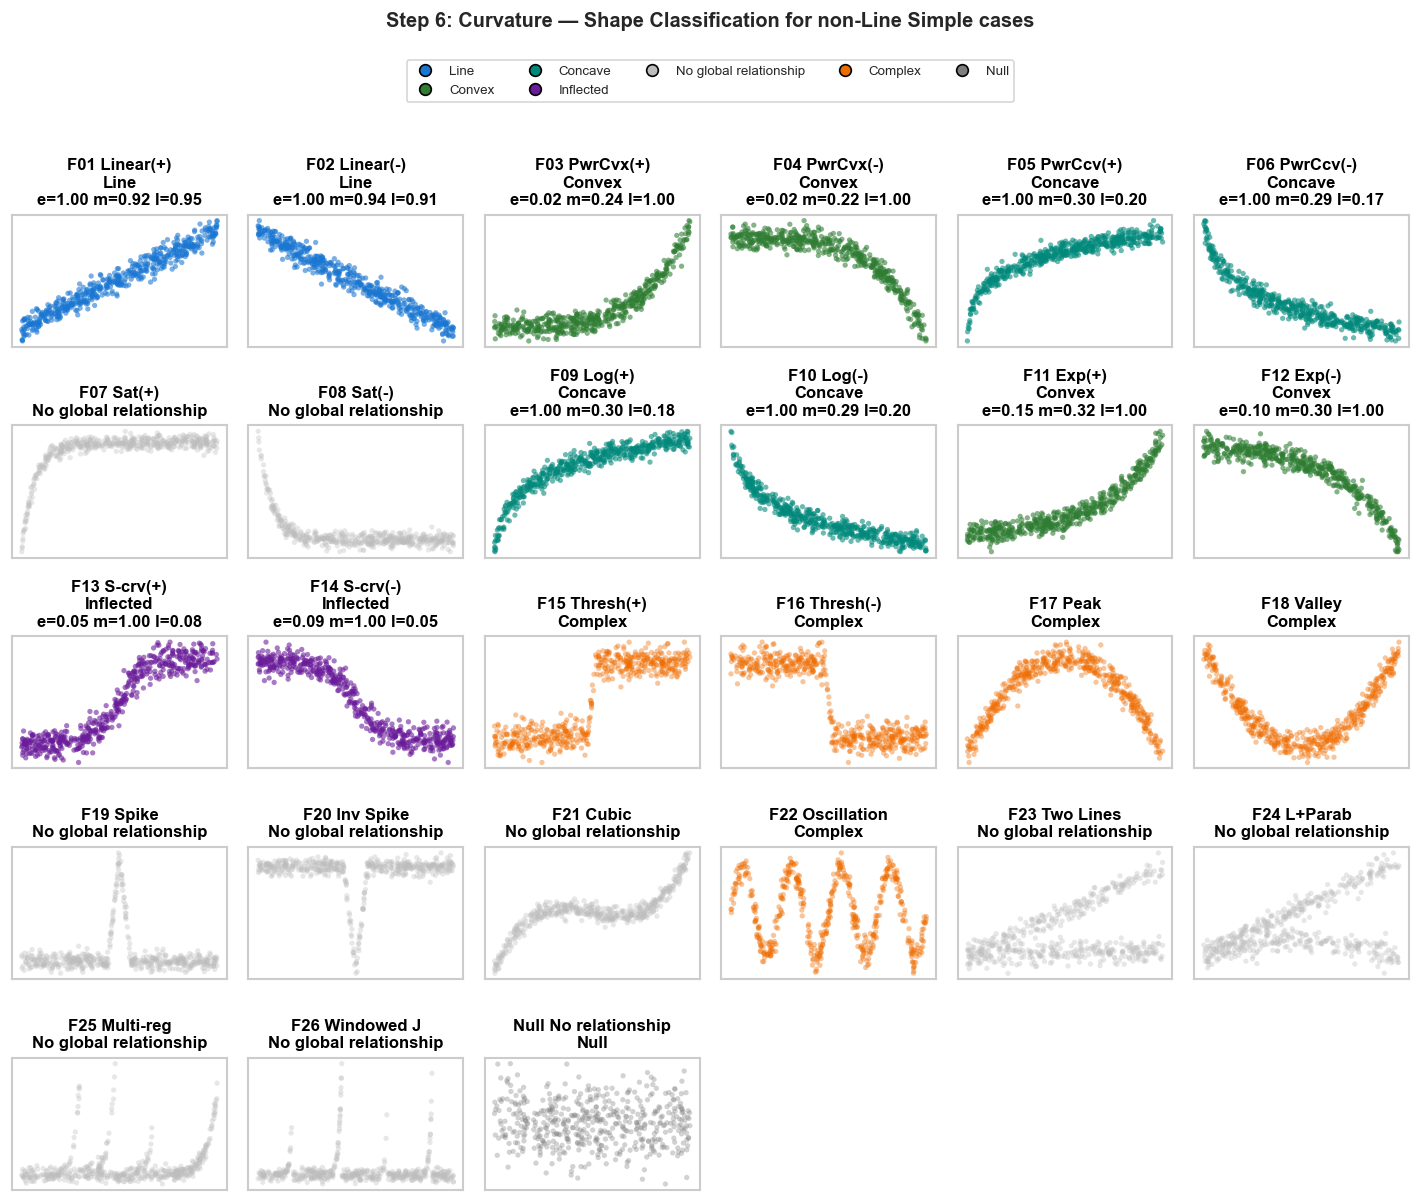

In [21]:
# ── Plot Step 6: Shape on 27-case grid ──
SHAPE_COLORS = {
    'Line': '#1976D2',
    'Convex': '#2E7D32',
    'Concave': '#00897B',
    'Inflected': '#6A1B9A',
    'Weak/Uncertain': '#757575',
    'No global relationship': '#BDBDBD',
    'Complex': '#EF6C00',
    'Null': '#7E7E7E',
}

# Merge shape back to cases_27
for col in ['shape_tree', 'slope_Vs']:
    cases_27 = cases_27.drop(columns=[col], errors='ignore')
cases_27 = cases_27.merge(
    simple_cases_27[['case_id', 'shape_tree', 'slope_Vs']],
    on='case_id', how='left'
)

fig, axes = plt.subplots(5, 6, figsize=(12, 10))
fig.suptitle('Step 6: Curvature — Shape Classification for non-Line Simple cases',
             fontsize=12, fontweight='bold', y=1.0)

for ax, (_, row) in zip(axes.flat, cases_27.iterrows()):
    idx = case_idx_by_id.get(row['case_id'])
    if row['simple_complex_label'] == 'Simple':
        label = row['shape_tree']
        color = SHAPE_COLORS.get(label, '#757575')
        alpha = 0.58
    elif row['simple_complex_label'] == 'Complex':
        label = 'Complex'
        color = SHAPE_COLORS['Complex']
        alpha = 0.40
    elif row['family_id'] == 'Null':
        label = 'Null'
        color = SHAPE_COLORS['Null']
        alpha = 0.35
    else:
        label = 'No global relationship'
        color = SHAPE_COLORS['No global relationship']
        alpha = 0.35

    if idx is not None:
        ax.scatter(x_all[idx], y_all[idx], s=10, alpha=alpha,
                   color=color, edgecolors='none')

    if row['simple_complex_label'] == 'Simple':
        ax.set_title(
            f"{row['family_id']} {row['short']}\n{label}\n"
            f"e={row['e_d']:.2f} m={row['m_d']:.2f} l={row['l_d']:.2f}",
            # f"span={row['slope_span']:.2f}  V_s={row['slope_Vs']:.2f}",
            fontsize=10, fontweight='bold', color='black'
        )
    else:
        ax.set_title(
            f"{row['family_id']} {row['short']}\n{label}",
            fontsize=10, fontweight='bold', color='black'
        )
    ax.set_xticks([])
    ax.set_yticks([])

for ax in axes.flat[len(cases_27):]:
    ax.set_visible(False)

handles = [Line2D([0], [0], marker='o', color='none', markerfacecolor=SHAPE_COLORS[k],
                  markersize=7, label=k)
           for k in SHAPE_COLORS if k in set(cases_27['shape_tree'].dropna()) |
           {'No global relationship', 'Complex', 'Null'}]
fig.legend(handles=handles, loc='upper center', ncol=min(5, len(handles)),
           fontsize=8, frameon=True, bbox_to_anchor=(0.5, 0.965))

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

## Final — Combined Tree Result

Full classification: Global → Simple/Complex → Direction → Monotonicity → Linearity → Shape

In [22]:
# ── Final tree label ──
cases_27['final_tree_label'] = np.select(
    [
        cases_27['family_id'] == 'Null',
        cases_27['simple_complex_label'] == 'No global relationship',
        cases_27['simple_complex_label'] == 'Complex',
        cases_27['simple_complex_label'] == 'Simple',
    ],
    [
        'Null',
        'No global relationship',
        'Complex',
        cases_27['shape_tree'].fillna('Simple: unclassified'),
    ],
    default='Unclassified'
)

print('═══ Final Tree Classification ═══')
print(cases_27['final_tree_label'].value_counts(dropna=False).to_string())

═══ Final Tree Classification ═══
final_tree_label
No global relationship    9
Complex                   5
Convex                    4
Concave                   4
Line                      2
Inflected                 2
Null                      1


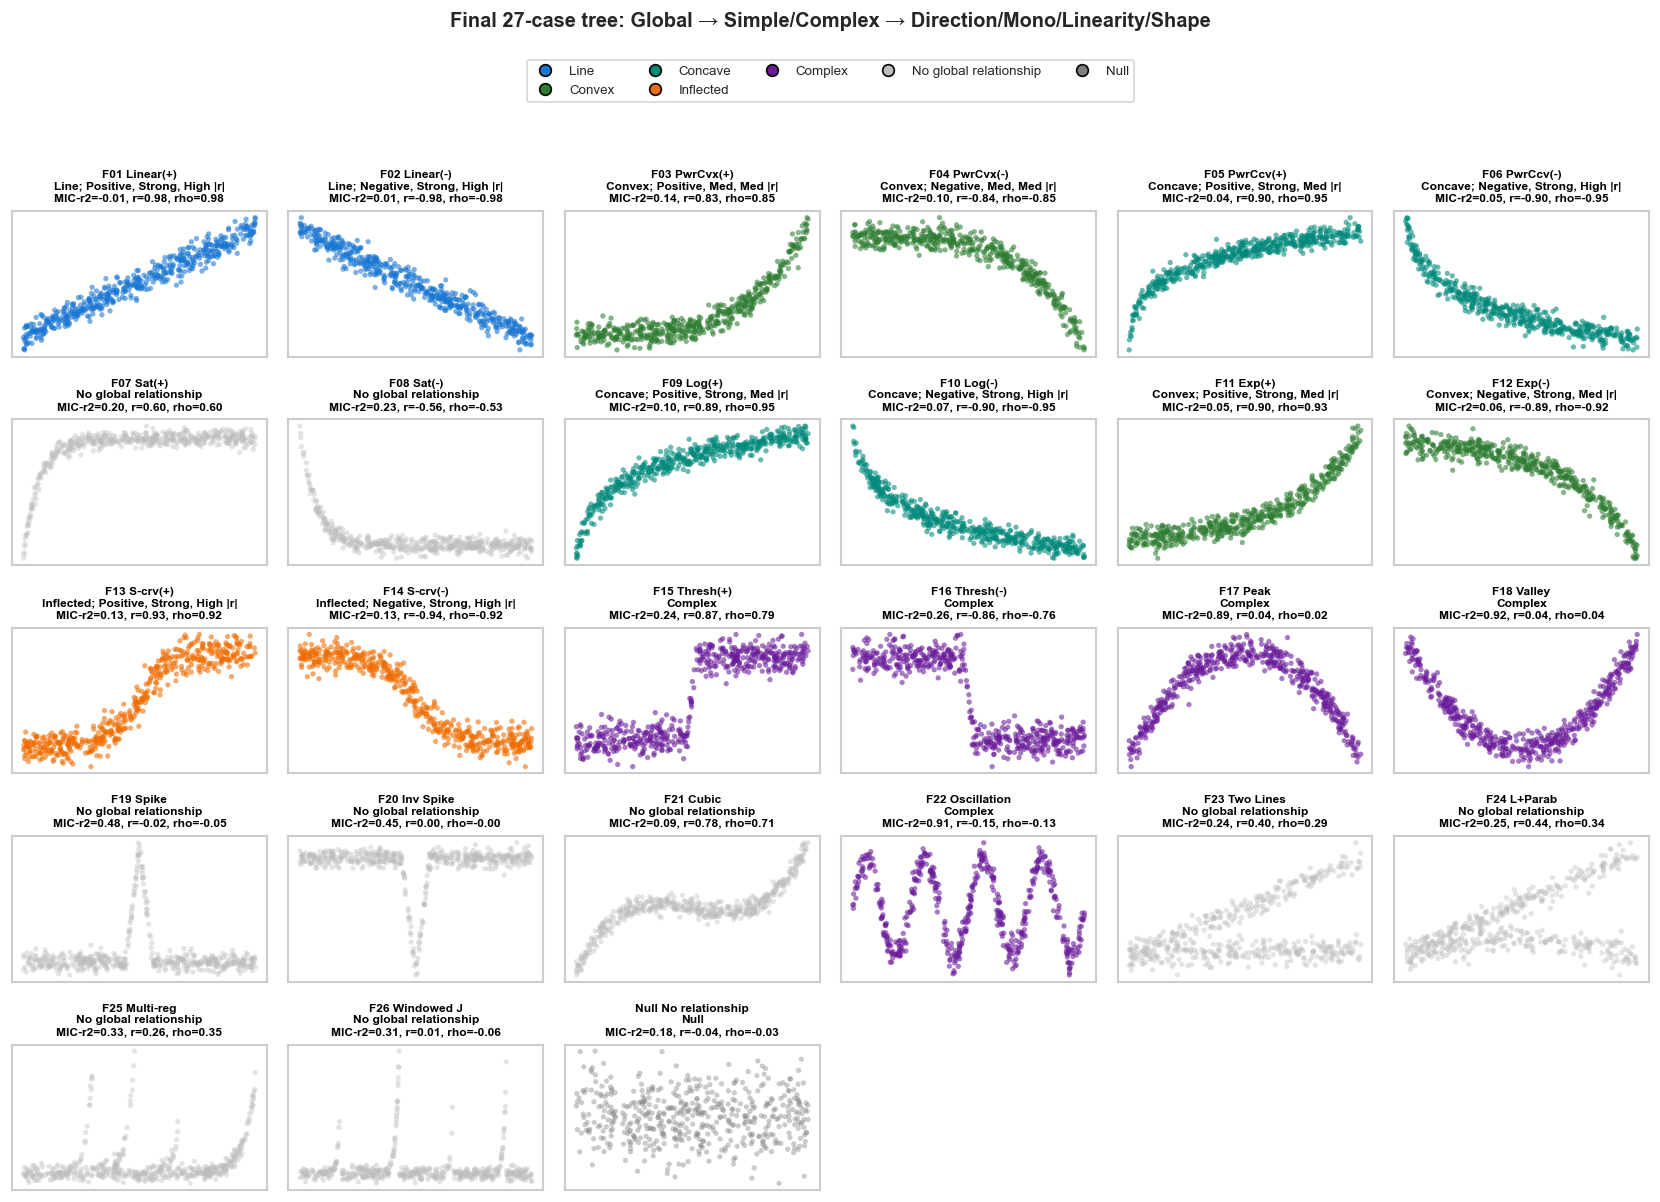

In [23]:
# ── Plot Final: full 27-case tree result ──
FINAL_COLORS = {
    'Line': '#1976D2',
    'Convex': '#2E7D32',
    'Concave': '#00897B',
    'Inflected': '#EF6C00',
    'Weak/Uncertain': '#757575',
    'Simple: unclassified': '#757575',
    'Complex': '#6A1B9A',
    'No global relationship': '#BDBDBD',
    'Null': '#7E7E7E',
    'Unclassified': '#424242',
}

fig, axes = plt.subplots(5, 6, figsize=(14, 10))
fig.suptitle('Final 27-case tree: Global → Simple/Complex → Direction/Mono/Linearity/Shape',
             fontsize=12, fontweight='bold', y=1.0)

for ax, (_, row) in zip(axes.flat, cases_27.iterrows()):
    idx = case_idx_by_id.get(row['case_id'])
    label = row['final_tree_label']
    color = FINAL_COLORS.get(label, '#424242')
    alpha = 0.58 if label not in ['No global relationship', 'Null'] else 0.40

    if idx is not None:
        ax.scatter(x_all[idx], y_all[idx], s=10, alpha=alpha,
                   color=color, edgecolors='none')

    if row['simple_complex_label'] == 'Simple':
        subtitle = f"{label}; {row['direction_tree']}, {row['monotonicity_tree']}, {row['linearity_tree']}"
    else:
        subtitle = label

    ax.set_title(
        f"{row['family_id']} {row['short']}\n{subtitle}\nMIC-r2={row['MIC_minus_r2']:.2f}, r={row['pearson_r']:.2f}, rho={row['spearman_rho']:.2f}",
        fontsize=7.2, fontweight='bold', color='black'
    )
    ax.set_xticks([])
    ax.set_yticks([])

for ax in axes.flat[len(cases_27):]:
    ax.set_visible(False)

handles = [Line2D([0], [0], marker='o', color='none', markerfacecolor=FINAL_COLORS[k],
                  markersize=7, label=k)
           for k in FINAL_COLORS if k in set(cases_27['final_tree_label'])]
fig.legend(handles=handles, loc='upper center', ncol=min(5, len(handles)),
           fontsize=8, frameon=True, bbox_to_anchor=(0.5, 0.965))

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

In [24]:
# ── Final 27-case classification summary ──
summary_cols = [
    'family_id', 'short', 'global_label', 'simple_complex_label',
    'direction_tree', 'monotonicity_tree', 'linearity_tree',
    'shape_tree', 'final_tree_label',
    'MIC', 'distance_correlation', 'MIC_minus_r2', 'MAS',
    'pearson_r', 'spearman_rho', 'slope_Vs',
]

display(cases_27[summary_cols].round(3))

,family_id,short,global_label,simple_complex_label,direction_tree,monotonicity_tree,linearity_tree,shape_tree,final_tree_label,MIC,distance_correlation,MIC_minus_r2,MAS,pearson_r,spearman_rho,slope_Vs
0,F01,Linear(+),Global relationship,Simple,Positive,Strong,High |r|,Line,Line,0.944,0.973,-0.010,0.022,0.977,0.978,0.034
1,F02,Linear(-),Global relationship,Simple,Negative,Strong,High |r|,Line,Line,0.967,0.973,0.011,0.039,-0.978,-0.978,0.038
2,F03,PwrCvx(+),Global relationship,Simple,Positive,Med,Med |r|,Convex,Convex,0.830,0.864,0.139,0.081,0.832,0.850,1.003
3,F04,PwrCvx(-),Global relationship,Simple,Negative,Med,Med |r|,Convex,Convex,0.803,0.870,0.104,0.044,-0.836,-0.848,1.028
4,F05,PwrCcv(+),Global relationship,Simple,Positive,Strong,Med |r|,Concave,Concave,0.842,0.926,0.040,0.047,0.896,0.945,0.717
5,F06,PwrCcv(-),Global relationship,Simple,Negative,Strong,High |r|,Concave,Concave,0.862,0.926,0.051,0.025,-0.901,-0.955,0.754
6,F07,Sat(+),No global relationship,No global relationship,NaN,NaN,NaN,NaN,No global relationship,0.558,0.642,0.201,0.051,0.597,0.603,NaN
7,F08,Sat(-),No global relationship,No global relationship,NaN,NaN,NaN,NaN,No global relationship,0.550,0.617,0.234,0.070,-0.562,-0.531,NaN
8,F09,Log(+),Global relationship,Simple,Positive,Strong,Med |r|,Concave,Concave,0.887,0.921,0.096,0.021,0.889,0.952,0.736
9,F10,Log(-),Global relationship,Simple,Negative,Strong,High |r|,Concave,Concave,0.883,0.926,0.069,0.024,-0.902,-0.955,0.725
